# Clustering Candidates Analysis

In [ ]:
import os, sys
import polars as pl
import numpy as np
from db_robust_clust.models import SampleDistClustering
from db_robust_clust.plots import clustering_MDS_plot_one_method
from kmedoids import KMedoids
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from robust_mixed_dist.quantitative import euclidean_dist_matrix

pl.Config.set_fmt_str_lengths(5000)

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.clustering_analysis_utils import (
    get_SampleDistClustering_results,
    get_KMeans_results
)

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

In [18]:
QUANT_COMPARISON_COLS = [
    'political_stance_score', 
    'argument_quality_score', 
    'sentiment_score'
]

CAT_COMPARISON_COLS = [
    'discourse_tone_score_label', 
    'dominant_frame_score_label', 
    'argument_quality_score_label', 
    'sentiment_score_label', 
    'political_stance_score_label'
]

CAT_COMPARISON_ORDER = {
    'political_stance_score_label': [
        'Strongly Pro-Palestine',
        'Leaning Pro-Palestine',
        'Neutral / Balanced',
        'Leaning Pro-Israel',
        'Strongly Pro-Israel'
    ],
    'sentiment_score_label': [
        'Very Negative',
        'Moderately Negative',
        'Mildly Negative',
        'Neutral',
        'Mildly Positive',
        'Moderately Positive',
        'Very Positive',
    ],
    'argument_quality_score_label': [
        'Spam / Non-Argument',
        'Pure Reaction', 
        'Bare Opinion',
        'Justified Opinion',
        'Reasoned Argument',
        'Sophisticated Discourse'
    ]
}

In [19]:
N_CLUSTERS_LIST = range(2,5)


## Clustering I: Data - Discursive Scores

In [20]:
numerical_cols = [
    'sentiment_score'
]

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols + ordinal_cols
binary_cols = []
multiclass_cols = nominal_cols 

SampleDistClustering-KMedoids-PAM - k=2


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


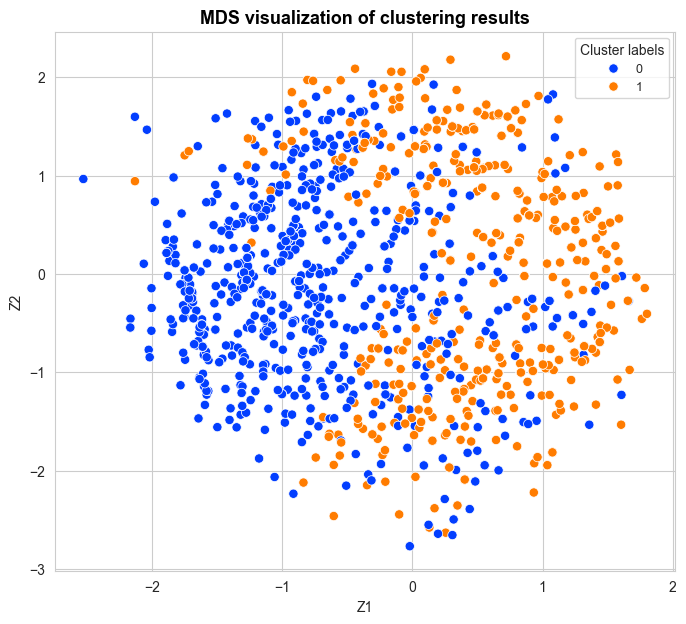

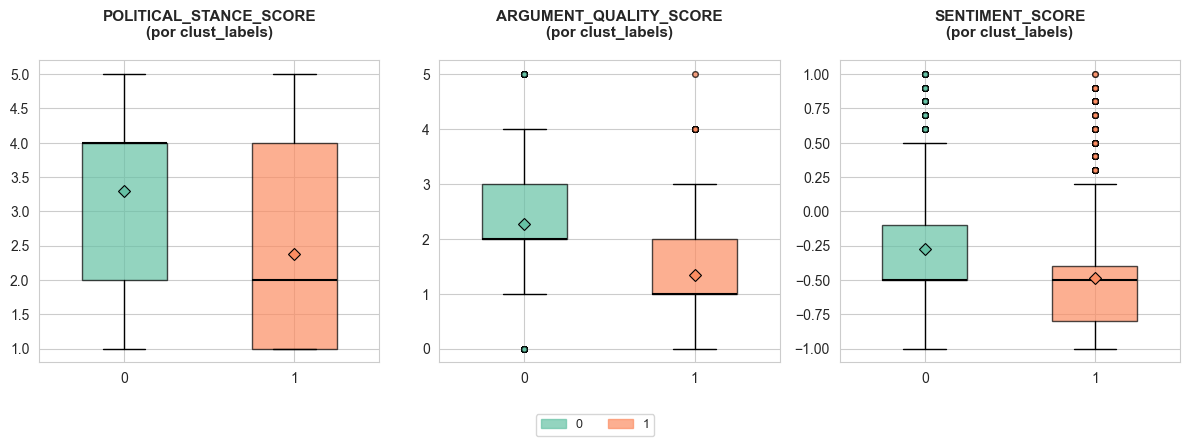

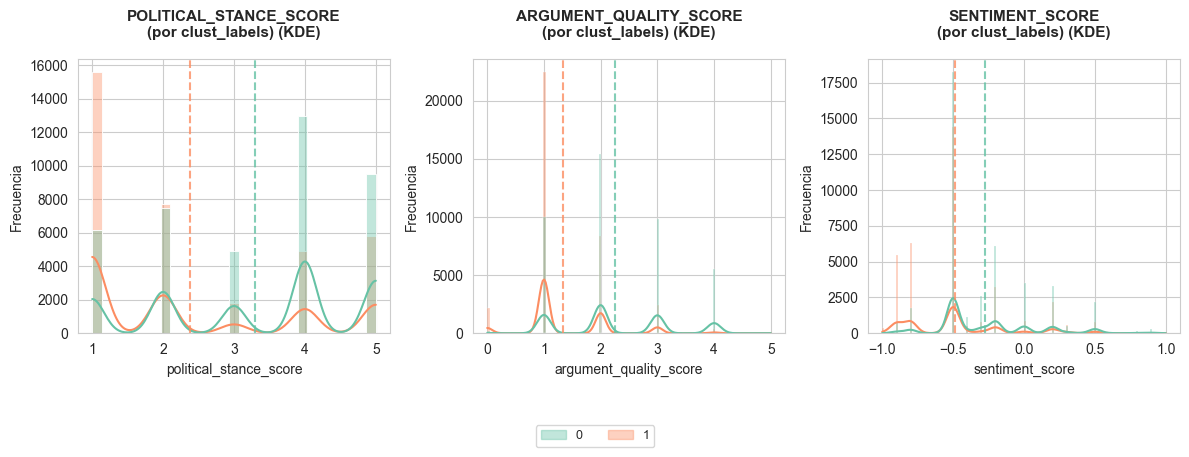

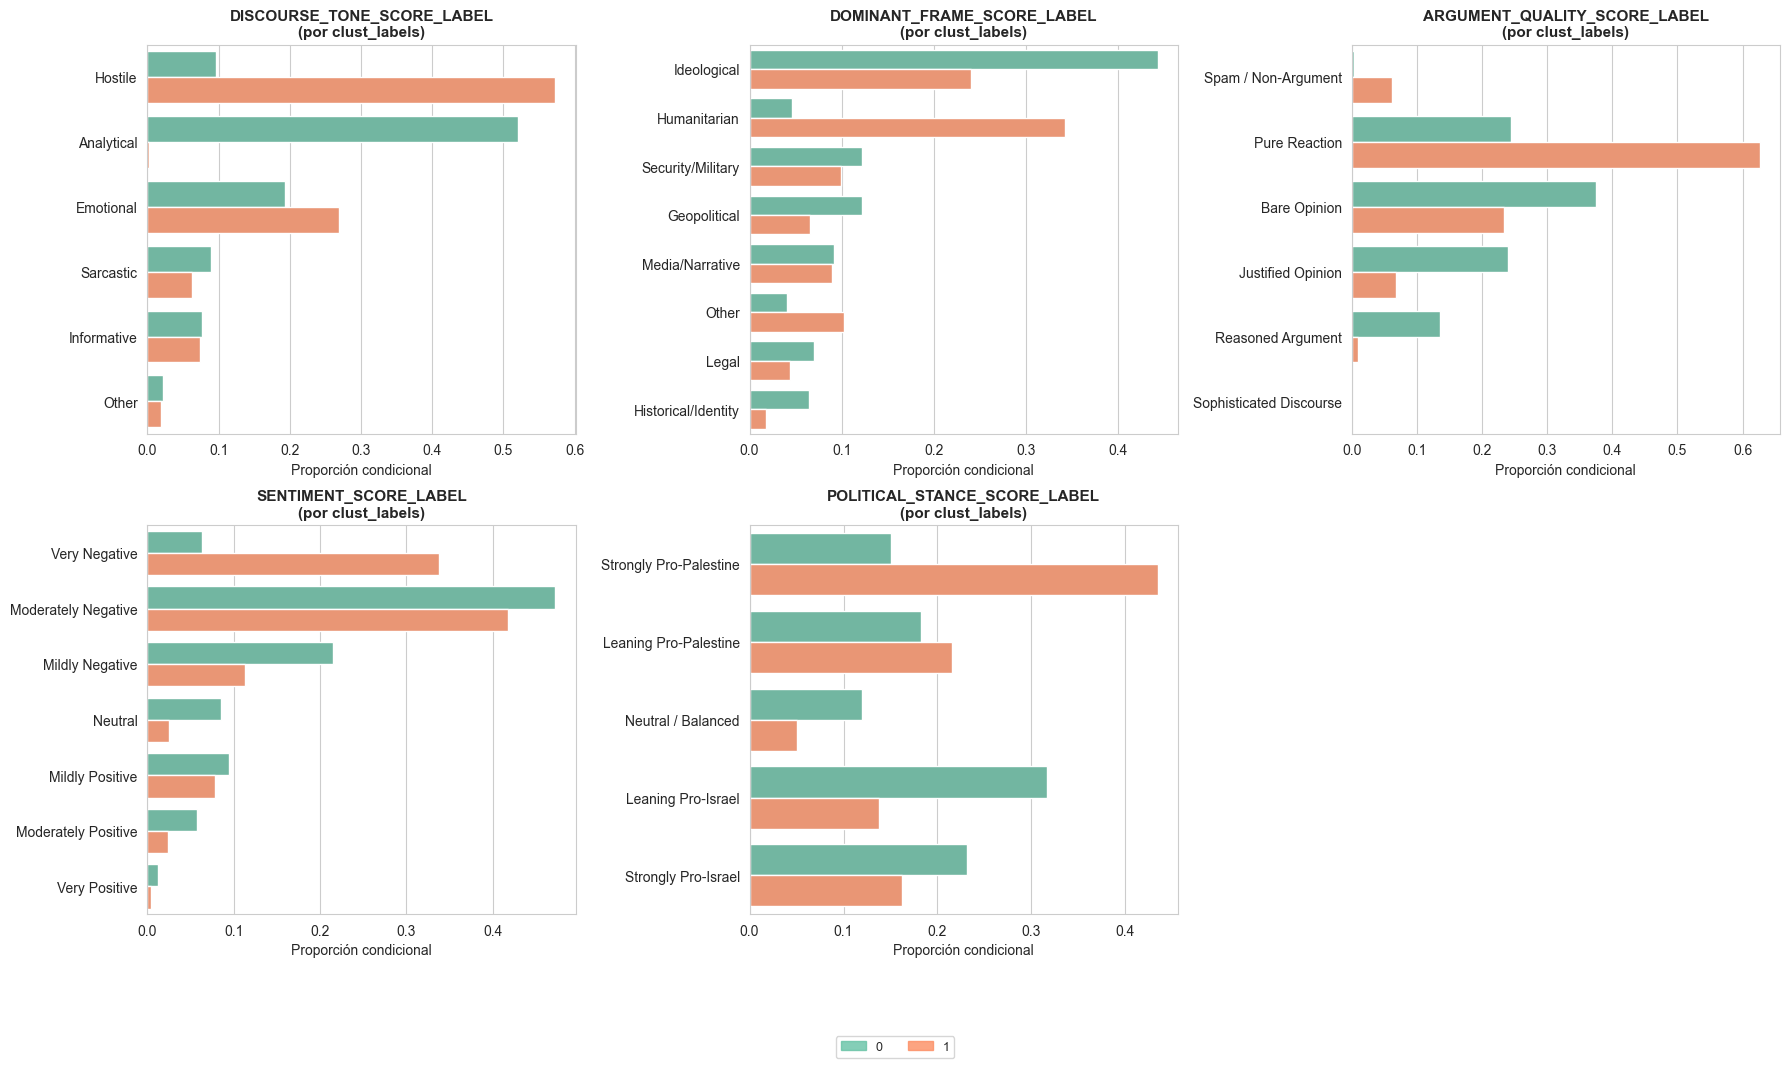

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""Being Israeli is not political""","""That's what it feels like these days online. That being Israeli, just the act of existing as a citizen of Israel, is a political statement to the rest of the world at large. I am Israeli. It doesn't matter what my political views are. It doesn't matter if I support our government, or not. If you wanted to condemn me, condemn me for my actions. But I am not a monster for leftists in the US to slay. I am Israeli. And that is not a political statement. Same as being any other flavor of person under the sun.""","""When I bash Israel I'm bashing the government and military, not the citizens or country generally""","""Analytical""","""Ideological""","""Bare Opinion""","""Mildly Negative""","""Neutral / Balanced"""
"""It's not antisemitic to criticize Israel; thus, it should not be antisemitic to criticize George Soros.""","""I do not believe at all that it is antisemitic to criticize Israel and its actions during the current conflict going on in that region. I don't necessarily agree with every single one of the criticisms that are levied against that country, however, I would never go so far as to say that all criticisms against it are inherently steeped in antisemitism. Yet, at the same time, I often see any attacks that are levied against the lefist activist and money-man George Soros be quickly and categorically labeled as ""antisemitism"". Examples of such indictments have been put forward by many leftist organizations, such as: * The ADL: ""[The Antisemitism Lurking Behind George Soros Conspiracy Theories](https://www.adl.org/resources/article/antisemitism-lurking-behind-george-soros-conspiracy-theories) * The Southern Povert Law Center: ""[Far Right Uses Antisemitic George Soros Trope To Attack Campus Protests](https://www.splcenter.org/resources/hatewatch/far-right-uses-antisemitic-george-soros-trop…","""If it's a specific criticism of something he's actually doing, sure. But many of the charges leveled against him are suspicious, to say the least.""","""Analytical""","""Ideological""","""Bare Opinion""","""Mildly Negative""","""Neutral / Balanced"""
"""Anti-Zionism is functionally indistinguishable from antisemitism, even if not all anti-Zionists are consciously or intentionally antisemitic""","""Anti-Zionism, as an ideology, is functionally indistinguishable from antisemitism, even if not all anti-Zionists are consciously or intentionally antisemitic (because there are many ignorant people). It uniquely targets the legitimacy of Israel as a Jewish state, while ignoring that countless other nations were founded through conquest, displacement, or conflict — often on a far greater scale. Countries such as the United States, Australia, Turkey, and even many modern European states emerged from histories soaked in blood, colonization, and systemic oppression. The same can be said for most if not all today's Muslim countries. Yet these are rarely questioned for their right to exist. Israel alone is singled out — not merely criticized for specific policies, but for existing at all — despite being the only Jewish state in the world and a refuge born from centuries of persecution. At its core, anti-Zionism denies Jews, as an ethnic and religious group, the same right to national self-d…","""I don't want to get into whether it's antisemitism or not. But Anti-Zionism, when used by people, doesn't always mean no existence of Israel at all. Sometimes it means being against Israeli expansionism beyond the 1967 borders.""","""Analytical""","""Ideological""","""Bare Opinion""","""Mildly Negative""","""Neutral / Balanced"""
"""How do you guys feel about the pro Palestine protesters who were against Biden for funding a “genocide” now against Trump because of his Gaza take over plans?""","""[https://youtu.b

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""""Here's another mother educating her child to become a terrorist... A mother with a keffiyeh on her stroller... your child will grow up to be a terrorist"" - An Israeli tourist in Italy is accusing mothers and their children of being terrorists for expressing solidarity with Palestine.""","""""","""Sorry buddy, welcome to a civilized country, where killing children is not normal.""","""Hostile""","""Humanitarian""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""I don't understand the massive support for palestine and I'll explain why""","""Here’s a concise list of major wars in the past 10 years where women and children have died: * **Syrian Civil War** – 15 Mar 2011 – *Ongoing* * **Yemeni Civil War** – 19 Mar 2014 – *Ongoing* * **Sudanese Civil War** – 15 Apr 2023 – *Ongoing* * **Myanmar Civil War** – 1 Feb 2021 – *Ongoing* * **Gaza–Israel War (current escalation)** – 7 Oct 2023 – *Ongoing* * **Russo–Ukrainian War** – 24 Feb 2022 – *Ongoing* * **Tigray War (Ethiopia)** – 3 Nov 2020 – 3 Nov 2022 *(ceasefire; violence continues in some areas)* * **Boko Haram Insurgency (Nigeria & Lake Chad region)** – 26 Jul 2009 – *Ongoing* * **Central African Republic Civil War** – 5 Dec 2012 – *Ongoing* * **South Sudanese Civil War** – 15 Dec 2013 – 22 Feb 2020 *(peace deal; sporadic violence continues)* **All major wars** in the last decade have killed women and children (directly or indirectly). Yet, only Palestine gets the massive support. It makes me wonder as a **non-Jew** and a **non-Muslim**, as to ""***why***""? Because, you …","""You know what's disgusting? The victims of these conflicts are rarely acknowledged, and when they are, it's for the laziest attempt at whataboutism. If you don't understand why eyes are focused on this conflict, you have a lot to learn about it.""","""Hostile""","""Humanitarian""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""It’s really dystopian to see people posting videos are like this while a couple of miles away, there is a famine. Anyone who still chooses to travel to Israel as a tourist is supporting a genocide but posting videos about food is just cruel.""","""""","""This is the same woman that went to Costco in Israel and was talking about all the food that there was. She is beyond tone deaf.""","""Hostile""","""Humanitarian""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""a sister carrying her baby brother out of their bombed house, they are the only survivors of their family .""","""So there's this one photo from Gaza that's been haunting me for two years now. It's of a sister carrying her baby brother out of their bombed house, they were the only ones in their family left. I only saw it once, right when the genocide started, but I couldn't forget it. Ended up spending days trying to find it online again. [source](https://web.archive.org/web/20231215210627/https://www.watanserb.com/2023/11/06/%D9%81%D9%8A%D8%AF%D9%8A%D9%88-%D9%85%D8%A4%D9%84%D9%85-%D9%84%D8%B5%D8%B1%D8%AE%D8%A7%D8%AA-%D8%B7%D9%81%D9%84%D8%A9-%D9%81%D9%84%D8%B3%D8%B7%D9%8A%D9%86%D9%8A%D8%A9-%D9%88%D9%87%D9%8A-%D8%AA%D8%AD/) ""","""Many people will probably call you pro-terrorism because you posted this image. Let that sink in.""","""Hostile""","""Humanitarian""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""Save the Children has suspended its work with Boston Consulting Group, calling the firm’s role in Gaza “utterly unacceptable.” BCG helped set up the US-Israeli shell organization, the Gaza Humanitarian Foundation, and modeled the forced relocation/ethnic cleansing of Palestinians.""","""""","""What the heck were they using them for in the first place? What's so complicated about feeding starving kids that 

SampleDistClustering-KMedoids-PAM - k=3


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


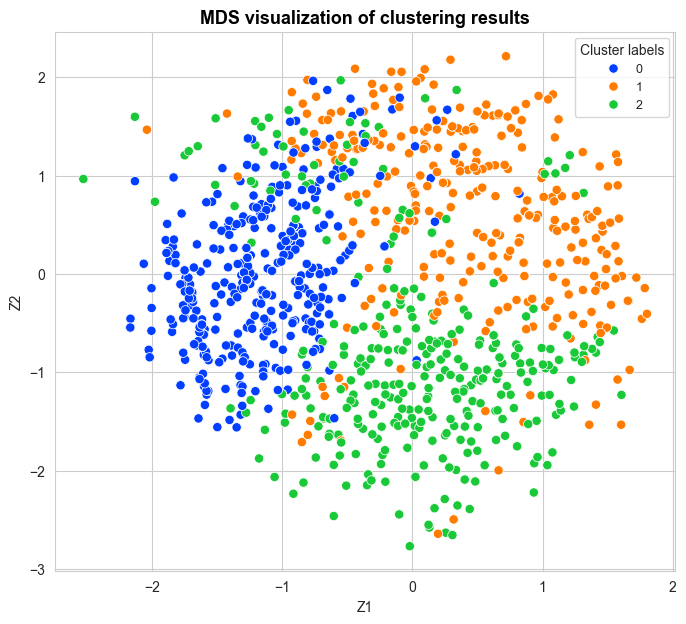

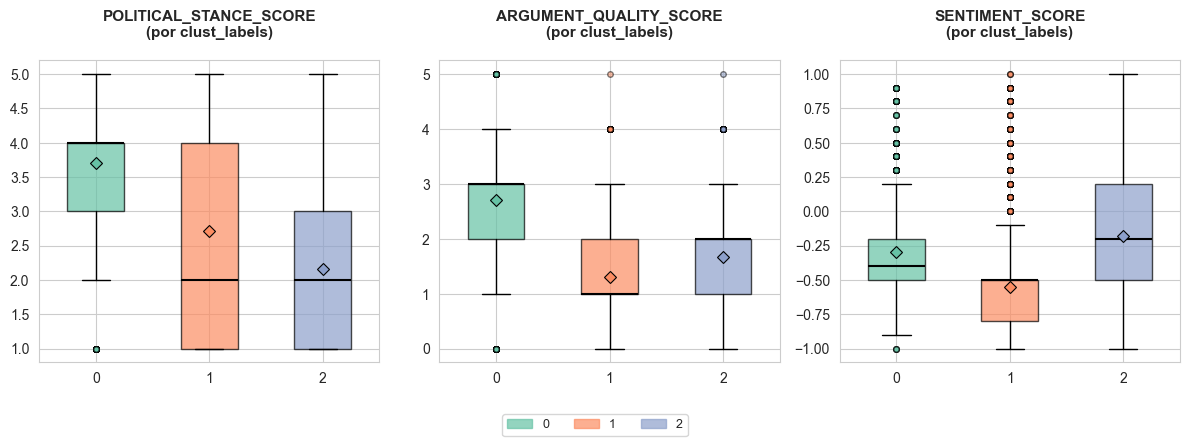

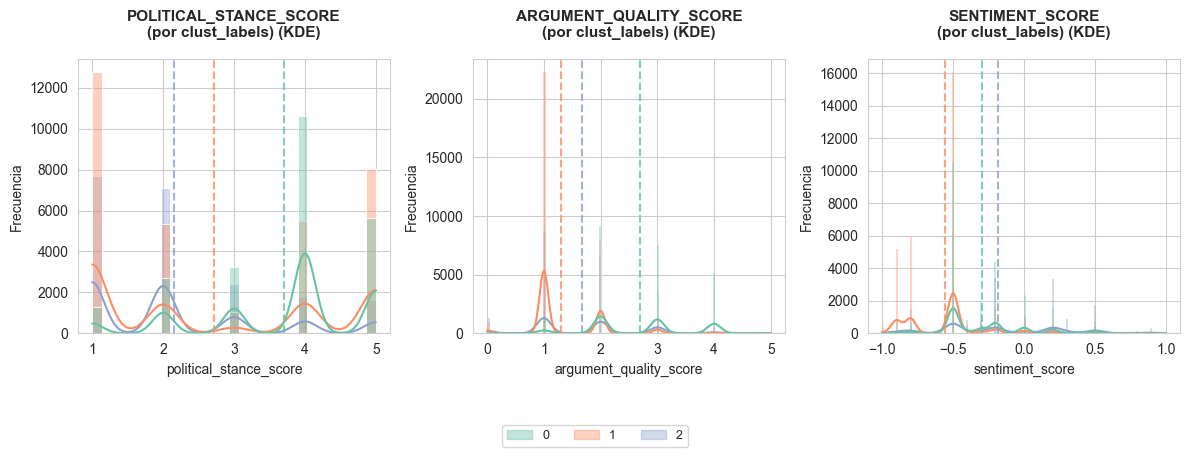

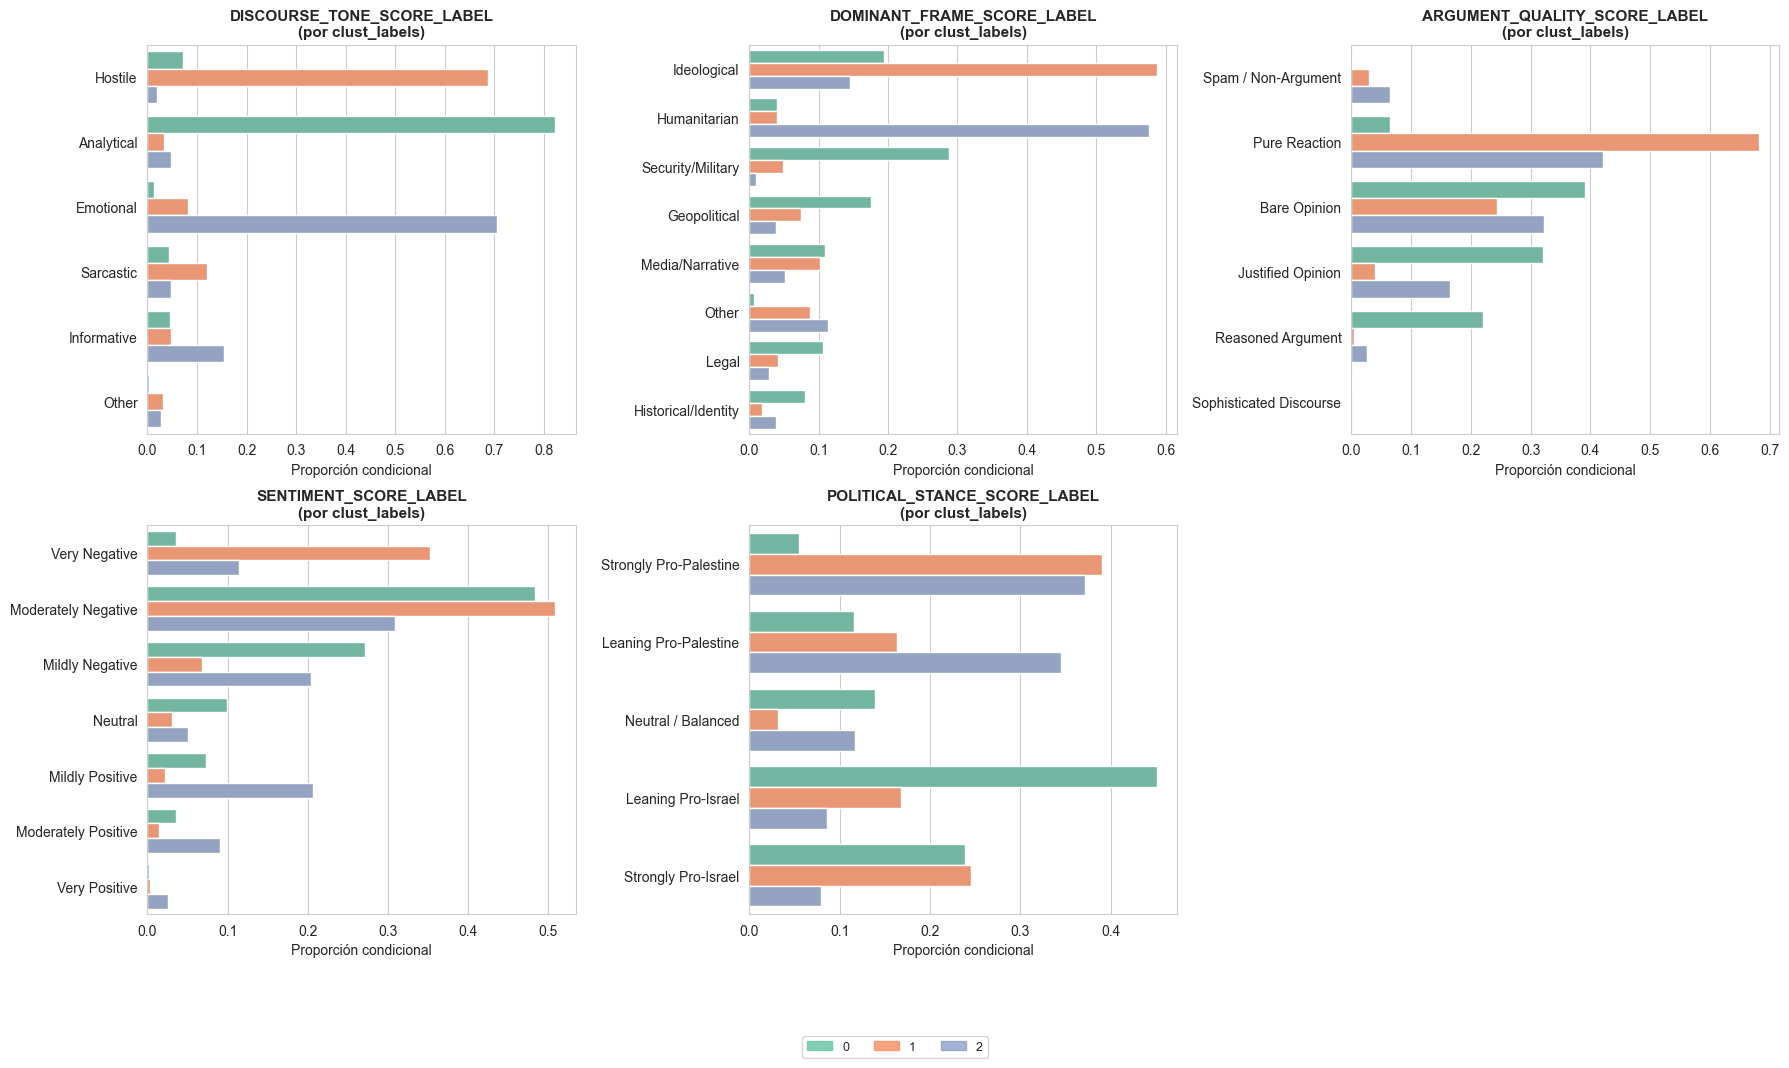

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""Could the preservation of the 2015 Iran Nuclear Deal have prevented the current conflict between Israel, Iran, and the United States?""","""In 2018, Donald Trump removed the United States from an agreement between seven nations (being Iran, U.K., France, Germany, Russia, China, and the U.S.) signed in 2015. On a high-level, the deal involved Iran respecting limits to the development of their nuclear program, allowing inspectors into nuclear facilities, and in exchange would receive relief from international sanctions. Trump repeatedly attacked the deal both on the campaign trail and in office, here are a few quotes: ""**The Iran Deal was one of the worst and most one-sided transactions the United States has ever entered into.**"" ""**This was a horrible one-sided deal that should have never, ever been made**"" ""**It didn’t bring calm, it didn’t bring peace, and it never will.**"" Obama responded by saying a withdrawal from the deal would be - ""**a losing choice between a nuclear-armed Iran or another war in the Middle East.**"" Macron had this to say: “**We would open the Pandora’s box. There could be war,**” The deal a…","""Probably, although the timing might have been different. From Israel's POV, there are actually two primary threats: Iran's nuclear program and their missile program. Besides what another poster mentioned on the deals limitations on the nuclear issue, it did nothing to address the missiles. Reports are that Iran had set a target to ramp up its missile production to build an arsenal of 10,000 missiles which could reach Israel, which basically make a nuke kind of redundant in the case of an attack on Israel. Given 7/10 - which Iran helped plan, although they apparently didn't know Sinwar was going to launch it when he did, Iran's support of Hizbullah's and the Houthi's attacks as well as the two Iranian missile attacks on Israel last year, Israel isn't currently in the mood to assume Iran doesn’t really mean to destroy it when it's hathering the means to do so.""","""Analytical""","""Security/Military""","""Justified Opinion""","""Mildly Negative""","""Leaning Pro-Israel"""
"""I’m so tired of this""","""With the famine in Gaza (caused by Hamas) being brought up a lot more recently and seeing ignorant non Jews making their ‘Israel are starving Gazans’ instagram stories, I’m just so tired of this. I’m so tired of people putting all The blame on Israel while they ignore the reason why this war is happening, because Hamas started it on 10/7 by murdering 1200 Israelis, kidnapping over 200, violently raping women. It’s always Israel is doing (insert lie) in Palestine/gaza. Their argument is never Hamas should release the remaining hostages and surrender. HAMAS COULD END THE WAR RIGHT NOW IF THEY JUST SURRENDER and release the remaining hostages. ""","""I have spoken to those in Israel asking them how is it that I could see what was going to happen and they didn't? Hamas invaded to get Israel to retaliate, and then were easily able to get the world to blame Israel. Hamas captured the food, we all know it, but why didn't Israel not merely make a big thing out of it, but let the various aid givers get killed or hurt by Hamas? We should have foreseen and acted early....""","""Analytical""","""Security/Military""","""Justified Opinion""","""Mildly Negative""","""Leaning Pro-Israel"""
"""Israel and Ukraine War Double Standards""","""i wanted to share with you something i have noticed about the reaction of the world to the 2 major wars being covered by the media - 1 - During Fenbruary 24 2022 Russia invaded Ukraine which started the war. more than 3 years have passed and since then Ukraine army in response to the invasion has killed so far more than 500,000 russians as self defense and in order to protect their country. 

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""Following a protest against Kahanist Israeli minister Itamar Ben-Gvir in New York, a pro-Israel mob chants ""death to the Arabs"" and harasses and assaults a lone woman""","""""","""This is the true face of contemporary Israel. Not the generic Trump supoorters who support Israel as a courtesy to him.""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""UNSC approves draft US resolution on Gaza with 13 votes in favor, while China and Russia abstained. The vote installs Jared Kushner & Tony Blair’s concept for a foreign “Board of Peace” as Gaza’s governing authority, giving it control over its resources and borders.""","""""","""And no representation for Gaza? Just these two robber barrons at the helm?""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""Israel: The only country that defends itself by expanding the war""","""Many Zionists are still claiming that Israel is acting in ""self-defense"" in Gaza - which is strange, considering they’re now [launching new airstrikes in Damascus](https://www.reuters.com/world/middle-east/clashes-resume-syrias-druze-city-sweida-after-ceasefire-announcement-2025-07-16/), allegedly to ""protect Druze communities."" And yet, somehow, we’re still pretending this is just about October 7. Let’s be honest: the idea that Gaza is *still* self-defense has been laughable for a while now. Yes, October 7 was horrific - and, contrary to what many seem to assume, most pro-Palestinian advocates acknowledge that. But there comes a point when ""self-defense"" becomes something else. And there comes another point when that something else demands to be examined and called out for what it actually is. Israel has flattened most of Gaza, displaced nearly the entire population, killed tens of thousands (including at least 15,000 children), and is now regularly bombing neighboring countries. W…","""I thought we were all against “genocide” and “ethnic cleansing” no? Is it cool when Syria does it to Druze now?""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""remember her name, from UAE.""","""""","""Why post this? What do we gain by publishing Zionist propaganda?""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""I think The food blockade of the last months was Israel's biggest mistake so far (in the war for hearts and minds)""","""I am not a military expert so I don't know how much it helped fight Hamas militarily. But since this is also a struggle for international support for both sides I think Israel made a big mistake by stopping food deliveries to Gaza. I know all the facts or claims that Hamas takes all the food to feed its fighters and sell the rest on the black market but still: The images that came out of Gaza and the headlines hurt Israel's reputation quite badly, I think. First, I saw it in my personal surroundings. I've seen people 'switch sides' and anti-Israeli voices have become much louder and got more support and 'likes' online. Second, even Germany has changed its rhetoric in the last 2 weeks or so. I know, Israel and the IDF need to do whats best in their opinion but Germany is usually a reliable supporter. Once you begin to lose them, I think it's time to reconsider. Even I, a 98% supporter of Israel, think those measures were too harsh. Even if it means more losses in the IDF and it mak…","""At the end of the day it’s not who does the dying it’s who does the killing - we all know the westerners didn’t protest for the 100s of thousands dead in Yemen, or Sudan.""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Leaning Pro-Pal

--------------------------------------------------
Medoid and KNN for Cluster 2:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""If Greta and the rest of the the Freedom Flotilla crew are murdered by Israel, the world will explode""","""There is a strong case to be made that Aaron Bushnell’s immolation on February 25th of last year strongly influenced students across the country and injected courage into them, and the willingness to withstand arrest, reproof, expulsion and physical injury. Columbia students encamped at their university on April 17th, igniting the students of the country. They were burning with Bushnell’s holy fire. If Greta and the Freedom Flotilla are murdered by Israel, this will light up the world with resistance. Greta is a universal figure, as Aaron has become. She is a moral leader of today, as are other rebels like her who resist the carbon death project to the point of being put in prison for years. Such as Roger Hallam and Indigo Rumblelow, cofounders of Just Stop Oil in the UK. Roger is serving 4 years in prison for promoting civil resistance on a Zoom call. Indigo is serving 2.5 years for planning to glue herself with others to the runway at Heathrow Airport demanding an end to oil and gas…","""I don't like thinking of her as a sacrifice to the world to stop Zionism, it gives me really bad chills all over....because in my mind's eye I can see that is a path. I don't want to see that, but I hope Greta secures herself & her crew because she is in grave danger.""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Mildly Negative""","""Leaning Pro-Palestine"""
"""Only two IDF soldiers killed in Gaza in August""","""Is Hamas finally running out of steam? Only two IDF soldiers killed all month, and only 8 rockets.""","""“Only two” families,kids,friends all lost two souls because of this war. Let’s not forget the other 800+ fallen idf soldiers this is not boasting this is coping with the death""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Mildly Negative""","""Leaning Pro-Palestine"""
"""Do pro Palestine people think its alright for Israeli civilians to die?""","""Recently with the strikes on Israel i've seen a lot of pro Palestine people be happy about and even celebrate people dying and saying they deserve it and im just really curious where this attitude is coming from Personally,i live in Israel,and my stance on the conflict is pretty netural,i dont like the death in Palestine but i dont support hamas in any way.I think civilians dying is not good no matter what side it is A common excuse to wishing death of everyone in Israel is that they are all guilty by living on stolen land/being in the army,which is just wrong,no one chooses where they are born,and the army is mandatory,most people (like my mom for example ) are just trying to live their life and didn't even serve an active military role (like my mom being a secretary for example),and i dont think its ok for you to wish people like that death? What happened to being humane and not wanting people to die? Another common thing i've seen is people commenting stuff along the lines of ""t…","""Civilians and children should not be part of any conflict ever, however its getting REALLY hard to care when all I see is palestinian population centers getting bombed every day.""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Mildly Negative""","""Leaning Pro-Palestine"""
"""Why can’t certain people believe that what is happening in Palestine is real?""","""I sat down with my boyfriend’s family last night for dinner (they are DIE HARD MAGA members). For some reason, my bf mentioned Palestine and immediately the table went off. I’ll save ya’ll the headache and summarize the key points of their “”argument””. I brought up how Israel is murdering Palestine and literally lying to the public of what actually is going on (via videos and numerous articles) - especi

SampleDistClustering-KMedoids-PAM - k=4


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


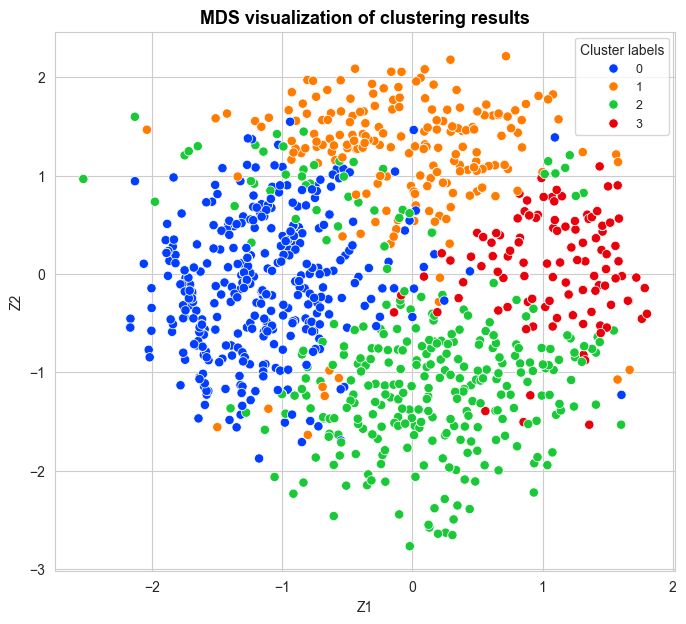

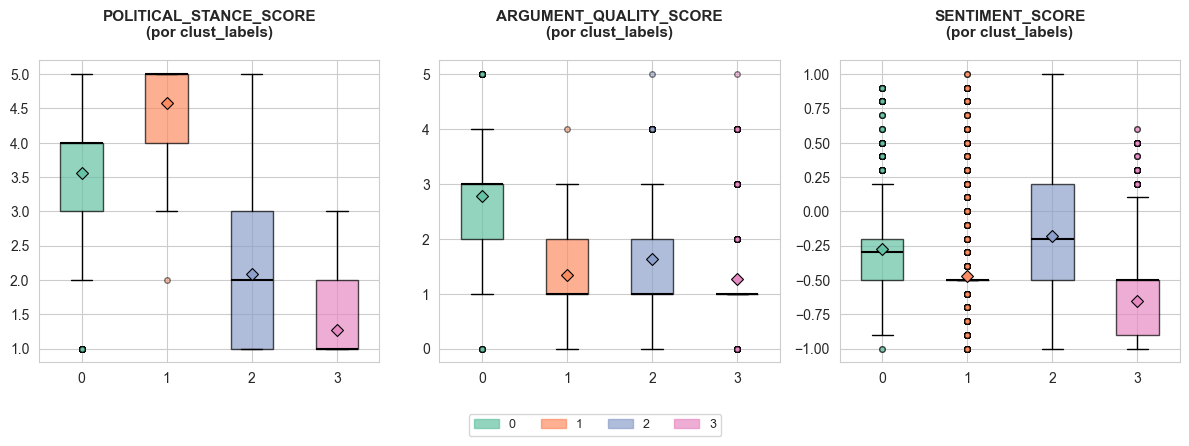

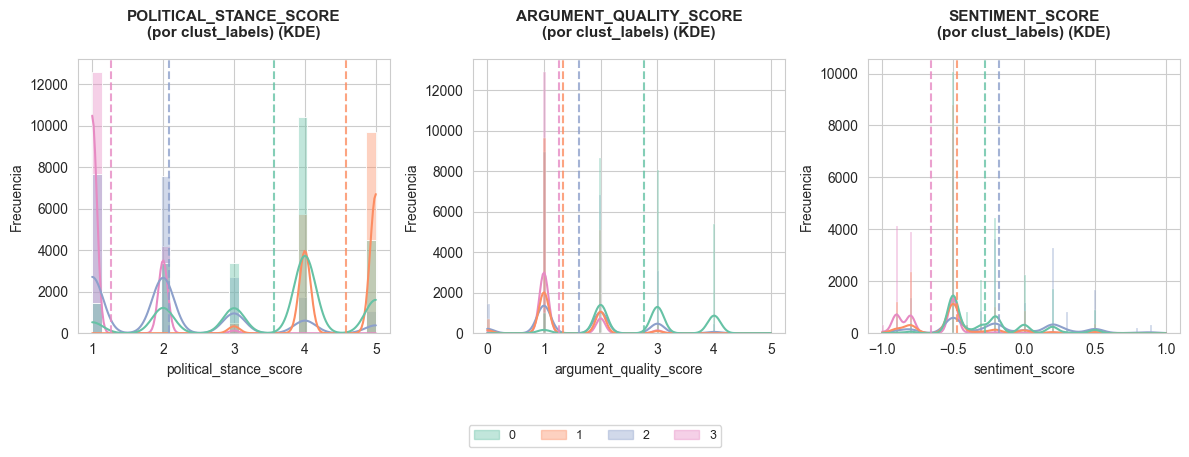

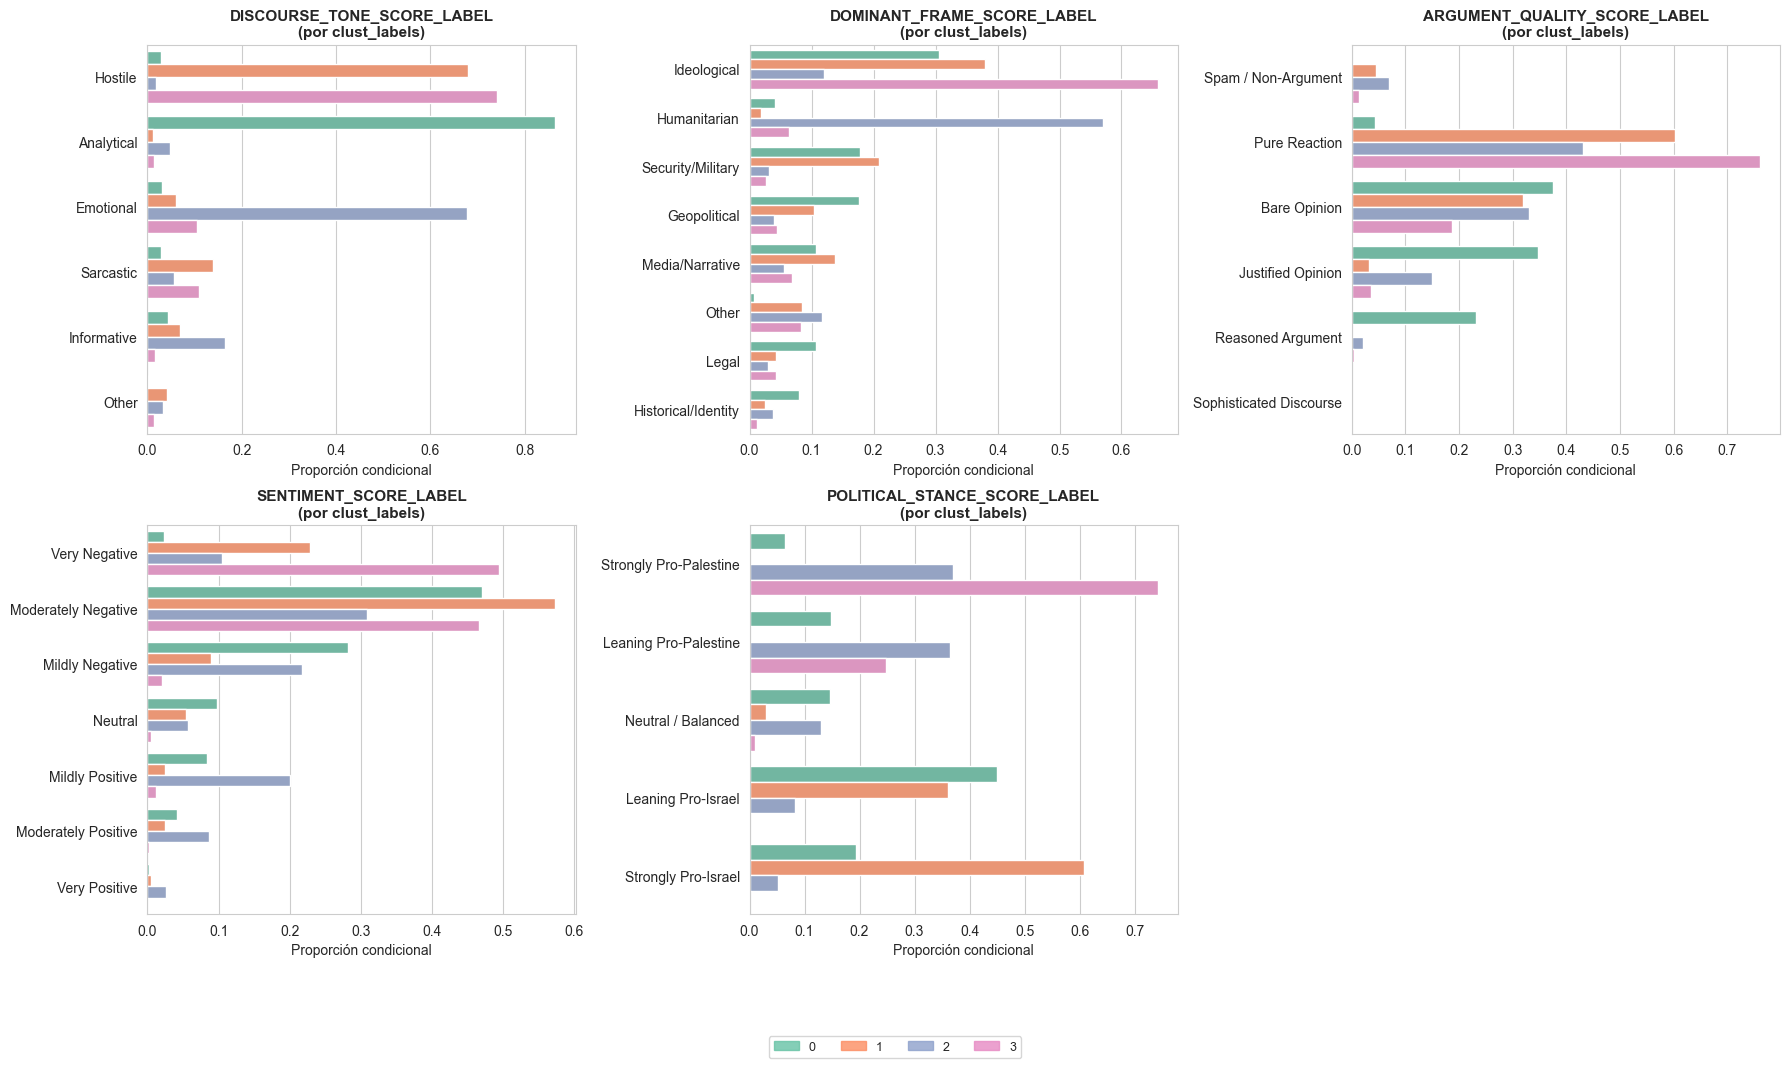

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""In NY (U.S.) pro-Israeli mob harassed a woman with ""Death to Arabs"" chants. Opinion?""","""Video can be found at another reddit post [here](https://www.reddit.com/r/WorldNewsHeadlines/comments/1kanko7/proisraeli_mob_harasses_woman_in_new_york_with/?utm_source=share&utm_medium=web3x&utm_name=web3xcss&utm_term=1&utm_content=share_button). A few questions on this shocking scene. Anyone knows who those extremists were? Why does American society (and Jewish community there) tolerate this kind of people? And a question for those pro-israelis who have problems with ""Free Palestine"" chants on pro-Palestinian demonstrations: do you have a problem with this ""**Death to Arabs**"" chant too or not really? Finally, imagine the opposite case, if the mob was pro-Palestinian harassing an israeli like that... pretty sure this subreddit would be burning in flames from anger and calling for those mobsters to be deported...""","""This behaviour is abhorrent. You can condemn this and still have a problem with the racist chants that come out of many pro-Palestine demonstrations. One does not cancel out the other. I’m not sure what point you’re trying to prove here. This is terrible AND there are many racist and violent things shouted about Israelis and Jews. By the way, the opposite case *did* happen when Arbel Yehud, who has held as a hostage in gaza for nearly 500 days, was nearly lynched by a violent massive mob of Palestinians.""","""Analytical""","""Ideological""","""Justified Opinion""","""Mildly Negative""","""Leaning Pro-Israel"""
"""Largest Teachers' Union in United States Erases Jews From the Holocaust""","""https://freebeacon.com/america/largest-teachers-union-in-united-states-erases-jews-from-the-holocaust/ The nation's largest teachers' union plans to promote a version of Holocaust remembrance that does not mention Jews, according to its 2025 handbook, which references ""victims of the Holocaust from different faiths"" and teaches that Israel was founded through ""forced, violent displacement and dispossession,"" its most recent guide for members shows. ... The handbook says the union will ""promote the celebration of International Holocaust Remembrance Day"" by ""recognizing more than 12 million victims of the Holocaust from different faiths, ethnicities, races, political beliefs, genders, and gender identification, abilities/disabilities, and other targeted characteristics."" The description does not mention the attempted extermination of the Jewish people by the Nazis. ... The book does, however, give a lengthy description of its plans to ""educate members and the general public about th…",""" The contemporary left, especially in the Anglophone world/United States, does not no where to place Jews in their cosmology. They see racism as bigotry plus power. If you are a victim of oppression or racism than this should manifest in terms of materially adverse outcomes and it should be systematic. In the English speaking countries Jews are generally seen as well educated, affluent, and not really suffering that much because they are Jews. Anti-Semitism doesn't make much sense in how it operates under this paradigm and they don't get it. A more sinister motive is that they see Israel and Zionism as illegitimate and they don't want to teach anything that might look like it might mean Zionism gets seen as anything but settler-colonialism.""","""Analytical""","""Ideological""","""Justified Opinion""","""Mildly Negative""","""Leaning Pro-Israel"""
"""'''Hottake''' that shouldn't be hot, if any freedom of Palestine even wants to happen, the Hamas HAVE to go.""","""I'm not really sure what flair to use for this, so 'ill just use ''Opinion''. Onto the subject, this is specifically a message to the people who side with Palestine that usually us

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""Queers for Palestine""","""Can someone explain to me how “ queers for Palestine” makes any sense. Israel is the only country in the Middle East that supports lgbtq people. There are actually massive pride parades there. Do people not get how it’s it is illegal to be queer in Palestine and how people can get killed for being gay there?? I’m going into my first year of university. I’m worried about going into the lgbtq spaces there because many people are pro Palestinian. The lgbtq club says that there should be no antisemitism but I highly doubt that’s the case because people can be antisemitic without knowing it. I wanted to take a course called women and gender studies but the syllabus says they are going to be reading books on Palestine. I’ve gone to a private Jewish school and now I’m going to be surrounded by many non Jews. ""","""People are stupid and uninformed. You can add a dash of antisemitism as well as""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Strongly Pro-Israel"""
"""Can a pro-palestinian explain how they think Israel should have reacted on October 7th and in general to things its enemies do?""","""Pro-palestinians like to talk about how Israel is doing things the wrong way I would like to know what would they do if placed in Israel's position as I do honestly believe Israel is doing the best it possibly can given the circumstances I would like to know what you would do in Israel's position to make a two state solution or any other peace deal with a group that consistently and openly calls for your destruction and says there is no way they will agree to a two state solution (examples from the Hamas founding documents) >''The Islamic Resistance Movement believes that the land of Palestine is an Islamic Waqf consecrated for future Moslem generations until Judgement Day. It, or any part of it, should not be squandered: it, or any part of it, should not be given up."" ""Initiatives, and so-call…","""I asked this once. I was told Israel 'should have apologized'. That was the day I realized the left had theorized itself into a moral abyss beyond recovery.""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Strongly Pro-Israel"""
"""The level of narcissism is off the charts""","""""","""""How dare you be anti-zionist when the weapons your police deploy against you are Israeli made""""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Strongly Pro-Israel"""
"""Event promotion Origin Sounds cancels Israeli DJ Roi Perez's show in London.""","""This comes after an article written by ""ravers""","""Not interested in learning from the Israeli side, I see. There will never be ""Palestinian liberation.""""","""Hostile""","""Ideological""","""Pure Reaction""","""Moderately Negative""","""Strongly Pro-Israel"""
"""Pro-Palestinians why is it so hard for you guys to admit that certain agencies/groups/ngo's are biased against / obsessed with hating on Israel?""","""I've been talking to pro-palestinians for a while and I've noticed a significant portion of Pro-Palestinians like to deny that agencies/groups/ngo's are in any way biased against / obsessed with hating on Israel despite many examples that make this fact pretty obviously true * the UNGA is biased against Israel despite facts like in 2024 the UNGA passed resolutions on: ISRAEL 17 Russia 1 Syria 1 North Korea 1 Iran 1 US 1 Sudan 1 Myanmar 1 Venezuela 0 Lebanon 0 Pakistan 0 Hamas 0 Algeria 0 Turkey 0 China 0 Qatar 0 Saudi 0 Cuba 0 Iraq 0 Afghanistan 0 * CNN in July, August, and September 2023 in the Middle East section on CNN.com 43 out of 99 were about Israel and this clearly this isn't about casualties because Sudan which had 3,595 conflict-related fatalities had only 2 a

--------------------------------------------------
Medoid and KNN for Cluster 2:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""Do pro Palestine people think its alright for Israeli civilians to die?""","""Recently with the strikes on Israel i've seen a lot of pro Palestine people be happy about and even celebrate people dying and saying they deserve it and im just really curious where this attitude is coming from Personally,i live in Israel,and my stance on the conflict is pretty netural,i dont like the death in Palestine but i dont support hamas in any way.I think civilians dying is not good no matter what side it is A common excuse to wishing death of everyone in Israel is that they are all guilty by living on stolen land/being in the army,which is just wrong,no one chooses where they are born,and the army is mandatory,most people (like my mom for example ) are just trying to live their life and didn't even serve an active military role (like my mom being a secretary for example),and i dont think its ok for you to wish people like that death? What happened to being humane and not wanting people to die? Another common thing i've seen is people commenting stuff along the lines of ""t…","""Civilians and children should not be part of any conflict ever, however its getting REALLY hard to care when all I see is palestinian population centers getting bombed every day.""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Mildly Negative""","""Leaning Pro-Palestine"""
"""2 years of genocide""","""""","""The air and water are totally contaminated with cement and other toxic substances. A lot of people are going to get sick. Unfortunately a lot of kids are going to have respiratory issues.""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Mildly Negative""","""Leaning Pro-Palestine"""
"""Can a pro-palestinian explain how they think Israel should have reacted on October 7th and in general to things its enemies do?""","""Pro-palestinians like to talk about how Israel is doing things the wrong way I would like to know what would they do if placed in Israel's position as I do honestly believe Israel is doing the best it possibly can given the circumstances I would like to know what you would do in Israel's position to make a two state solution or any other peace deal with a group that consistently and openly calls for your destruction and says there is no way they will agree to a two state solution (examples from the Hamas founding documents) >''The Islamic Resistance Movement believes that the land of Palestine is an Islamic Waqf consecrated for future Moslem generations until Judgement Day. It, or any part of it, should not be squandered: it, or any part of it, should not be given up."" ""Initiatives, and so-call…","""the goal of Israel should have been the liberation of Palestinians from Hamas. all they had to do was place the same value on Palestinian civilians as they would Israeli civilians ""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Mildly Negative""","""Leaning Pro-Palestine"""
"""Israeli people think gaza civilians can end the war""","""I recently saw a post here about a person asking what ordinary Gazans can do to end the war. The answers are really unfounded or even absurd, people repeat, as if they are paid for that, give back the hostages, or tell Israel where the hostages are. Revolt against hamas, things like that, and I don't know if you think it is very easy or if you really don't realize what you are saying. Imagine if it were the other way around, that in the Israel-Iran war, an Iranian would say, tell me where are Israel's nuclear weapons stockpiles and we will end the war, what would you tell him? You, citizen of Israel, do you know where your government keeps the nuclear weapons? Do you know where exactly are the prisons where the Palestinians are being held? Do you even have information from your government 

--------------------------------------------------
Medoid and KNN for Cluster 3:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""ISIS was added as an ally fighting besides Israel during the genocide on Gaza. More in the description.""","""This was added after Netenyahu publicly admitted that they were funding the ""Popular Forces"". As soon as it was up the Zionist propagandists were scrambling to get it removed from Wikipedia, instead they put the ""Popular Forces"" with Palestine flag next to them, now it looks like the second picture. When you click on popular forces you'll see their allegiance is to PA (bs) and to ISIS. They're still working tirelessly to remove any links to ISIS. You can check on the Wikipedia's edit history. However as well know, whatever is on the internet remains there forever. Ps: for anyone that says this is Wikipedia and anyone can edit it. True, but pages that are very controversial like this are usually locked and only verified users with a lot of experience are allowed to make edits, which then goes into revisions and get approved. There are people and bots that constantly monitor the slightest changes and revert them back within a second if they were deemed malicious or incorrect. You can t…","""https://preview.redd.it/h8awt86zu76f1.jpeg?width=1283&format=pjpg&auto=webp&s=c4420df004af7f191c18ec2a9d9121ede02c39b0 Israel and ISIS are one and the same.""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Piers Morgan has come so far on the issue of Gaza and Israel. My jaw is on the floor.""","""""","""""We would never do that."" ""It didn't happen."" ""It happens but not our fault."" ""It happens, but it's their fault and they deserve it.""""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""The UK has officially recognised Palestine""","""I have a lot to say on this, and it doesn’t change what’s happening on the ground, but as British-Palestinian I’m pleased with this development. This is huge. ""","""Hey Kier, you zionist prick, how about you actually protect the Palestinian people now?""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""~1,000 marched today near the Gaza border calling for an end to the starvation and war on Gaza""","""Marking Eid Al Adha, a relatively broad coalition of ~1,000 israeli jewish & palestinian left-wing and liberal activists led by the peace partnership and standing together marched along the Gaza border carrying food items and slogans against the war, against the starvation of gaza and calling for the return of the hostages. The food will be distributed in the west bank as aid cannot currently enter Gaza. It should be noted this was not an anti-zionist event but it marks a shift of a significant part of liberal israeli sentiment with regards to the war and genocide in Gaza. I designed and created the flag you see in the video, which reads ""No to starvation"". In the distance, plumes of smoke and fog envelop the northern Gaza strip. Once every few minutes, we heard an explosion and a strong smell of gunpowder lingered in the area. I wish more of us woke up from our complicity but I firmly believe this will not happen without foreign pressure. The labour aristocracy is all too comfortable …","""""See, we're a democracy!"" -Zionists after they couldn't suppress each and every protest. Those people should leave, divest themselves from, and revoke their citizenship with the fascist state. In staying they provide material and non-material support to the genociders. Leave that place. You will never be able to convince change from within a nation that knows damn well it is a racist and religious-extremist settler colonial project.""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Ge

In [ ]:
for n_clusters in N_CLUSTERS_LIST:

    get_SampleDistClustering_results(n_clusters, processed_data, quant_cols, binary_cols, multiclass_cols, QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER)

# Time: 10 mins

## Clustering II: Data - Discursive Scores + Embeddings

In [22]:
embeddings_cols = [col for col in processed_data.columns if 'embedding' in col]

numerical_cols = ['sentiment_score'] + embeddings_cols

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols
binary_cols = []
multiclass_cols = nominal_cols + ordinal_cols

SampleDistClustering-KMedoids-PAM - k=2


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


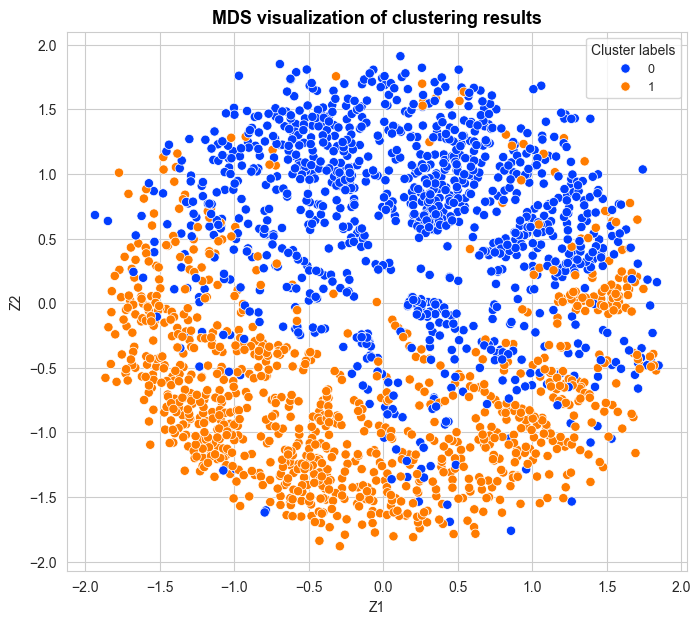

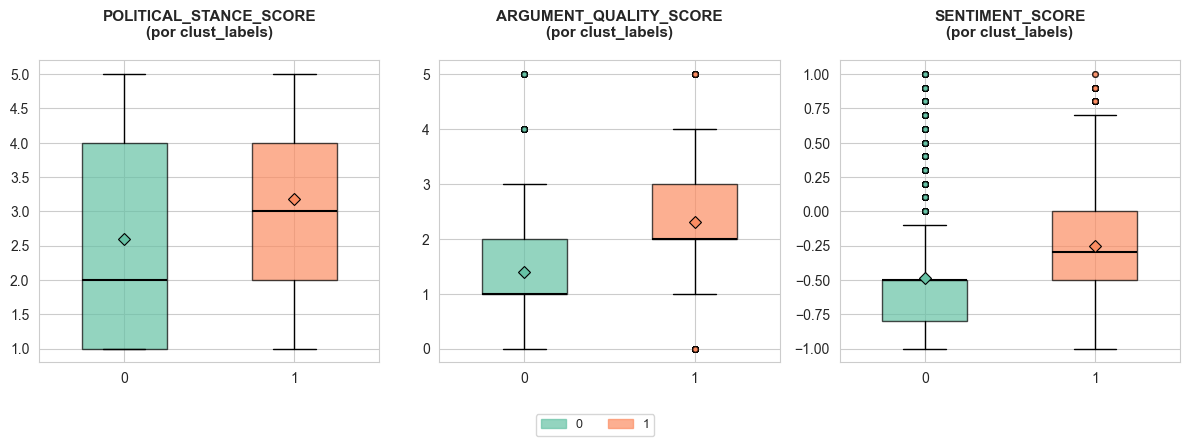

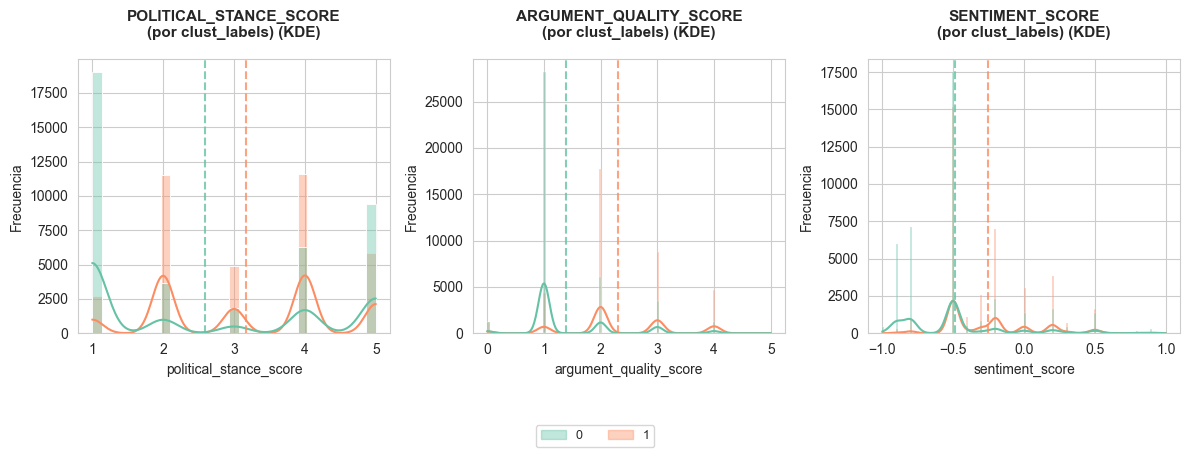

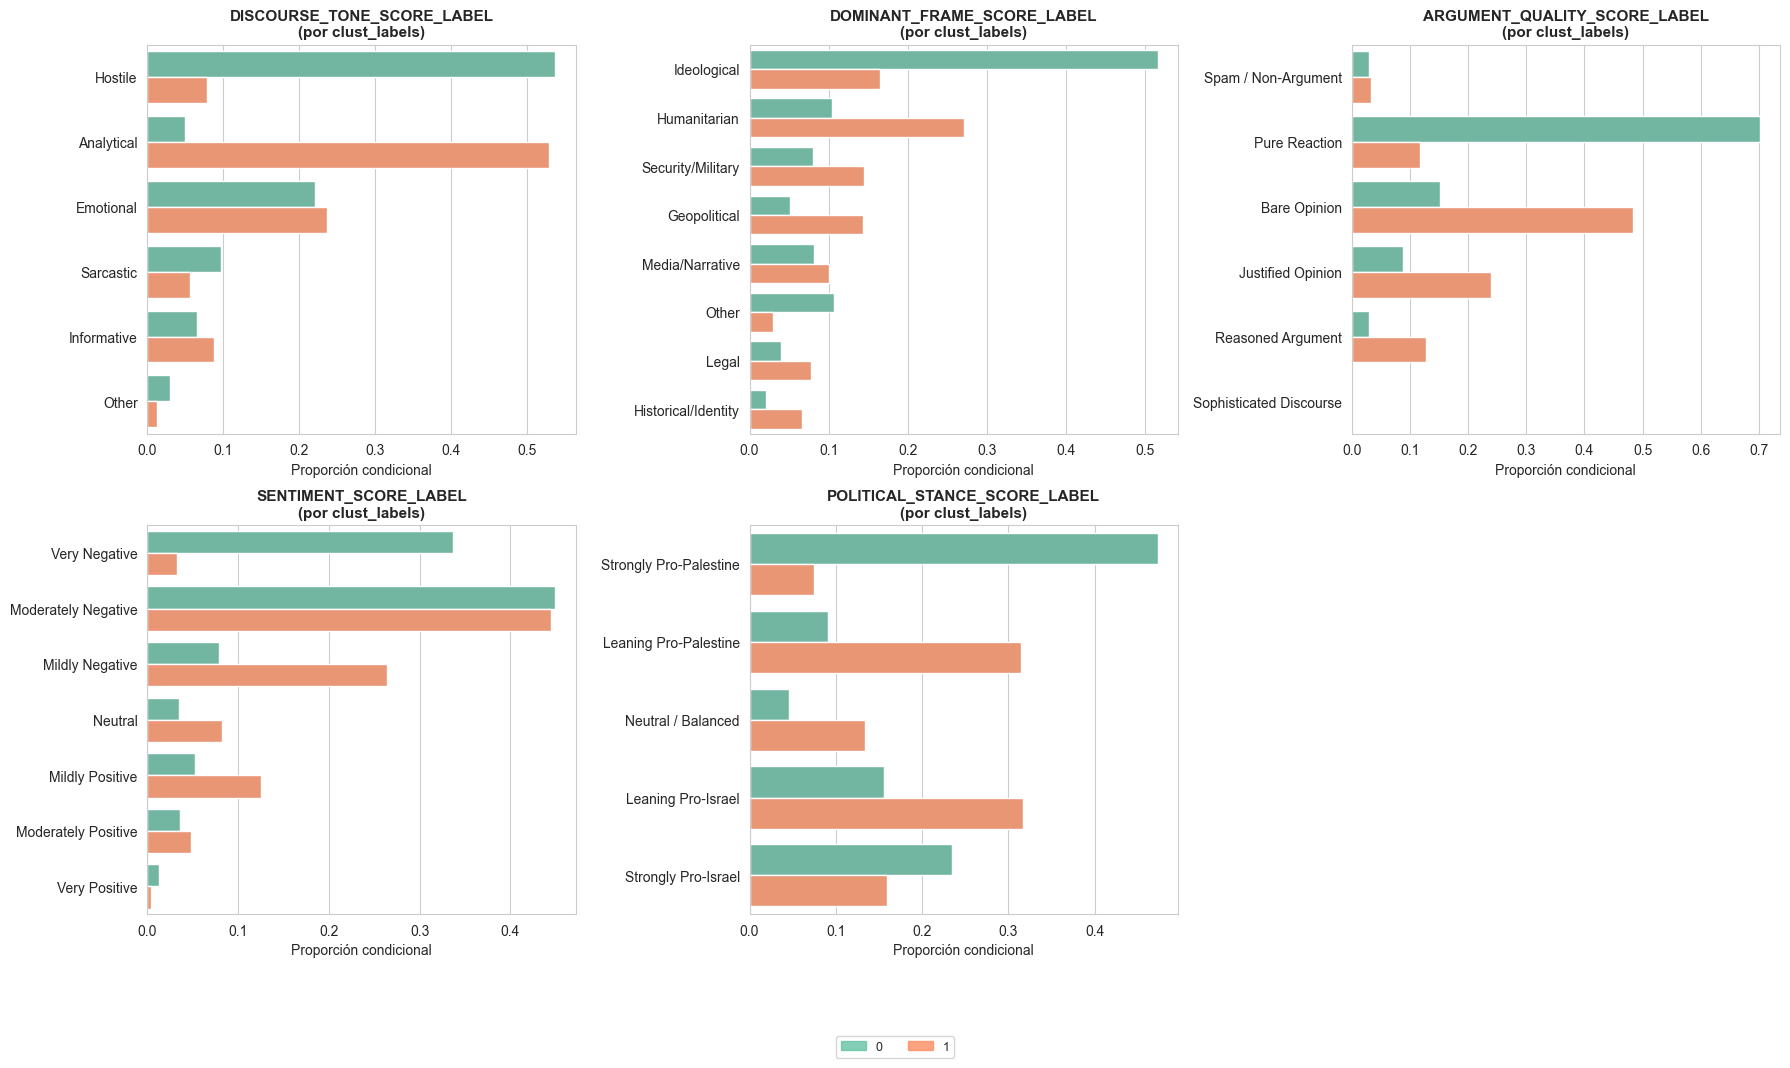

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""If Pro-Palestine “empathy” leads to more deaths, what are we actually supporting?""","""This is an honest to god question as I genuinely do not understand how people can look at this conflict and conclude that Israel is “the bad guy.” The war itself is tragic and nobody with a sense of humanity celebrates it, but when you look at the last 70 or 75 years, what is almost astounding to me, is how long it took to reach this point. Given the constant attacks, the explicit genocidal rhetoric, and the pattern of provocation since 1947, the idea that Israel is acting out of pure malice rather than accumulated context feels completely detached from reality. What makes this even stranger is that the conflict did not unfold in a vacuum. It sits inside a much larger regional pattern, the near total homogenisation of the MENA region over the last century. Armenians were exterminated in the Armenian Genocide, Assyrians slaughtered in the Assyrian Genocide, Greeks expelled, Jews driven out of Iraq, Egypt, Yemen and Syria, Christian communities shrinking everywhere from Lebanon to Gaza.…","""Israel IS THE BAD GUY. Why you ask? 70,000 killed by Israel in response to an attack. Lands stolen and continue to be stolen from Palestinians in the West Bank. Simple.""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Why are Palestine supporters so insufferable?""","""I want to start out by saying I oppose a significant amount of the things Israel is doing in Palestine, and think that Netanyahu is undisputedly a war criminal, and deserves jail. That being said it seems like the people supporting Palestine get more extremist every day. For example celebrating the October 7th attacks as some kind of heroic stand against tyranny. When in reality it was one of the deadliest terrorist attacks in history, and the catalyst for this entire war. If Hamas had never attacked on October 7th, there would be tens of thousands of Palestinians still alive. Another example is attacking anyone who even slightly supports Israel. AOC one of the most progressive people in Congress, and one of the biggest critics of Israel, just got death threats and her office vandalized for voting in favor of continuing to support the Iron Dome system in Israel, which is purely defensive. Or thinking that Biden/Harris would have been nothing different than Trump in their policy on Is…","""The more extreme Israel’s genocide the more extreme the opposition is going to be""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Israel is mostly in the right in the Israel-Palestine conflict""","""There were mass Arab pogroms of Jews before 1948 in the British mandate of Palestine, and tensions were only escalating. A single, independent state where Jews and Arabs lived together was never realistic. In 1948, at the time of independence, Israel was merely two tiny, disconnected pieces of land in the mandate of Palestine along the coast and towards the south in the Negev desert. Nevertheless, Israel accepted the partition and Jewish leaders like David Ben-Gurion and others called on the Arabs living there, 45% of the population at the time, to stay, promising equal rights. The *Declaration of the Establishment of the State of Israel* itself states: >""We appeal... to the Arab inhabitants of the State of Israel to return to the ways of peace and play their part in the development of the State, on the basis of full and equal citizenship and due representation in all its provisional and permanent institutions."" What did the Arabs do? The Arabs of Palestine rejected the partition, a…","""This is a hot, steaming pile of cope lol. If anyone looks up video of what is happening in Gaza, of what has 

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""The Two Standards""","""The posts on this board clearly reveal a mindset that believes this conflict should operate by two standards: one for the Israelis and one for the Palestinians. This mindset is Israel's enemy. Israel's enemy is not Hamas. Hamas is a reaction to this mindset, for sure. But Hamas can never destroy Israel. Israel certainly can destroy Israel, and it's doing exactly that. Israel has lost the majority of the support of its only friend, the United States. The latest Pew poll says that 48% support Israel. That number was as high as the upper 70s, and maybe as high as 80%. Even though the reasons for Israel's loss of support in the United States is plain as day, what does Israel do? Israel continues with the carnage and stands to lose more and more support of the people of the United States. And there is a tipping point. I don't know exactly what that is, but it must be lower than 2/3rds, or 66%. Israel seems determined to get there. Many people are saying that Israel is an e…","""Bunch of rambling but you do touch on an important point. That point is Israel has all the military power and might, no Palestinian group does. Which is an important note when every respectable human rights organisation states Palestinians have been under a brutal oppression since the day they were born. Yet you also say that is not evil, maybe our definitions of evil differ.""","""Analytical""","""Humanitarian""","""Bare Opinion""","""Mildly Negative""","""Leaning Pro-Palestine"""
"""Antizionists start with ""Israel is bad and evil"" and then work backwards to find reasons to justify their hatred""","""Antizionists start with ""Israel is bad and evil"" and then work backwards to find reasons to justify their hatred. That's why they question the establishment of a Jewish state 70 years later but question the establishment of no other states That's why they treat the war in Gaza as a ""genocide"" that must be protested with millions on the streets, while they have never bothered to protest the actual genocides where hundred of thousands are dying in Sudan and other places That's why they treat Palestinian displacement as some original sin that must be righted, while treating the millions of others (including Jews) who were displaced as some historical footnote that doesn't matter today That's why they claim their anger is because of Palestinians dying in the current war, even though their movement started protesting Israelis while Israelis were the ones dying That's why they think is evil that Jews have a state but fine that Muslims and Christians each have dozens That's why they act…","""Wrong on every level. In have many Jewish friends and colleagues who I like a lot. I just don't like what Israel is doing to Palestinians. It's literally that simple. I'm a humanitarian. And yes, I am against Hamas, and condemn what Hamas did on Oct. 7, and don't like Palestinians who want to kill Jews. None of those things justifies what Israel is doing to Palestinians. If that makes me an anti-Zionist, then that's what I am. I'm a humanitarian first though, and don't accuse me of something I am not.""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Mildly Negative""","""Leaning Pro-Palestine"""
"""Can you help me understand the way of thinking regarding continued support for Israel despite what are they doing in Gaza?""","""Let me start by saying (since there will be a lot of you saying ""but do you support Hamas?"" as a purity test) that I hate Hamas, and I wish it to be gone or not in power in Gaza, but not in the way the IDF is currently doing. I do not agree at all with what IDF is doing in gaza with what seems to be indiscriminate airstrikes, cutting off water and electricity or replacing aid with cement or things like how their troops

SampleDistClustering-KMedoids-PAM - k=3


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


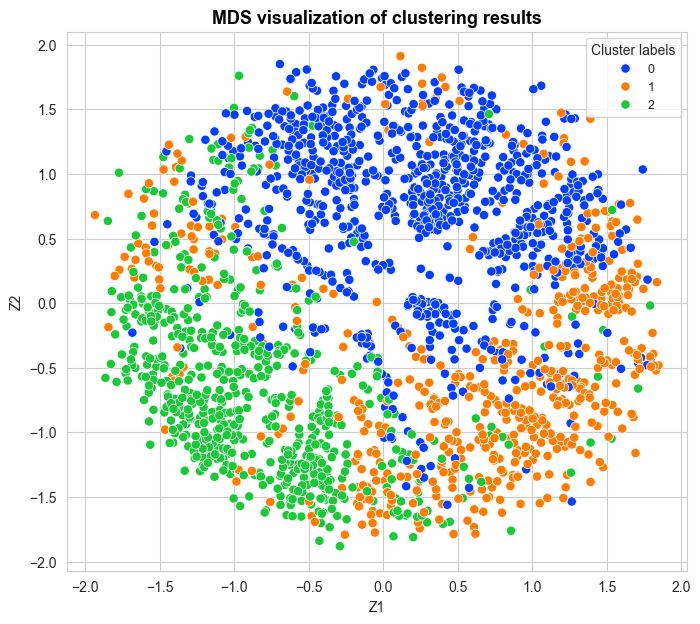

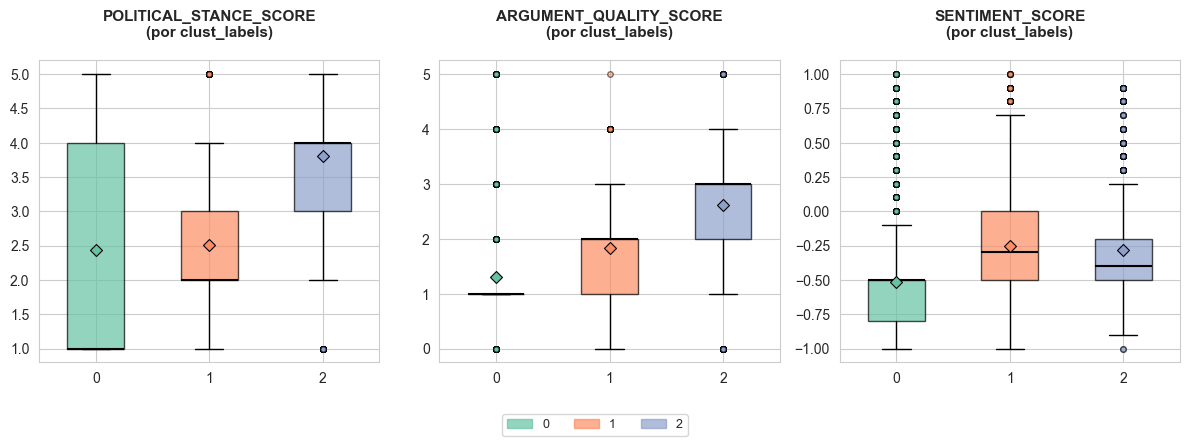

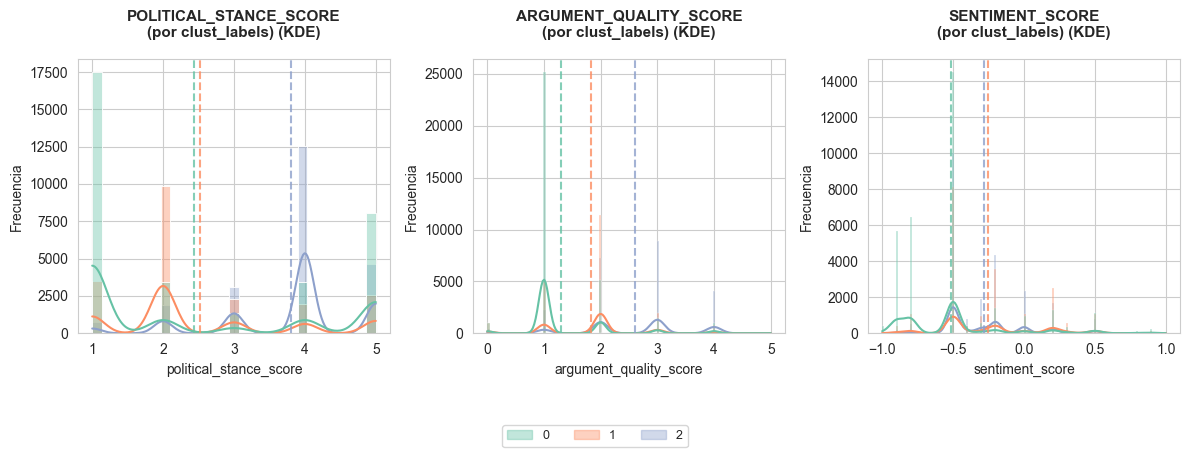

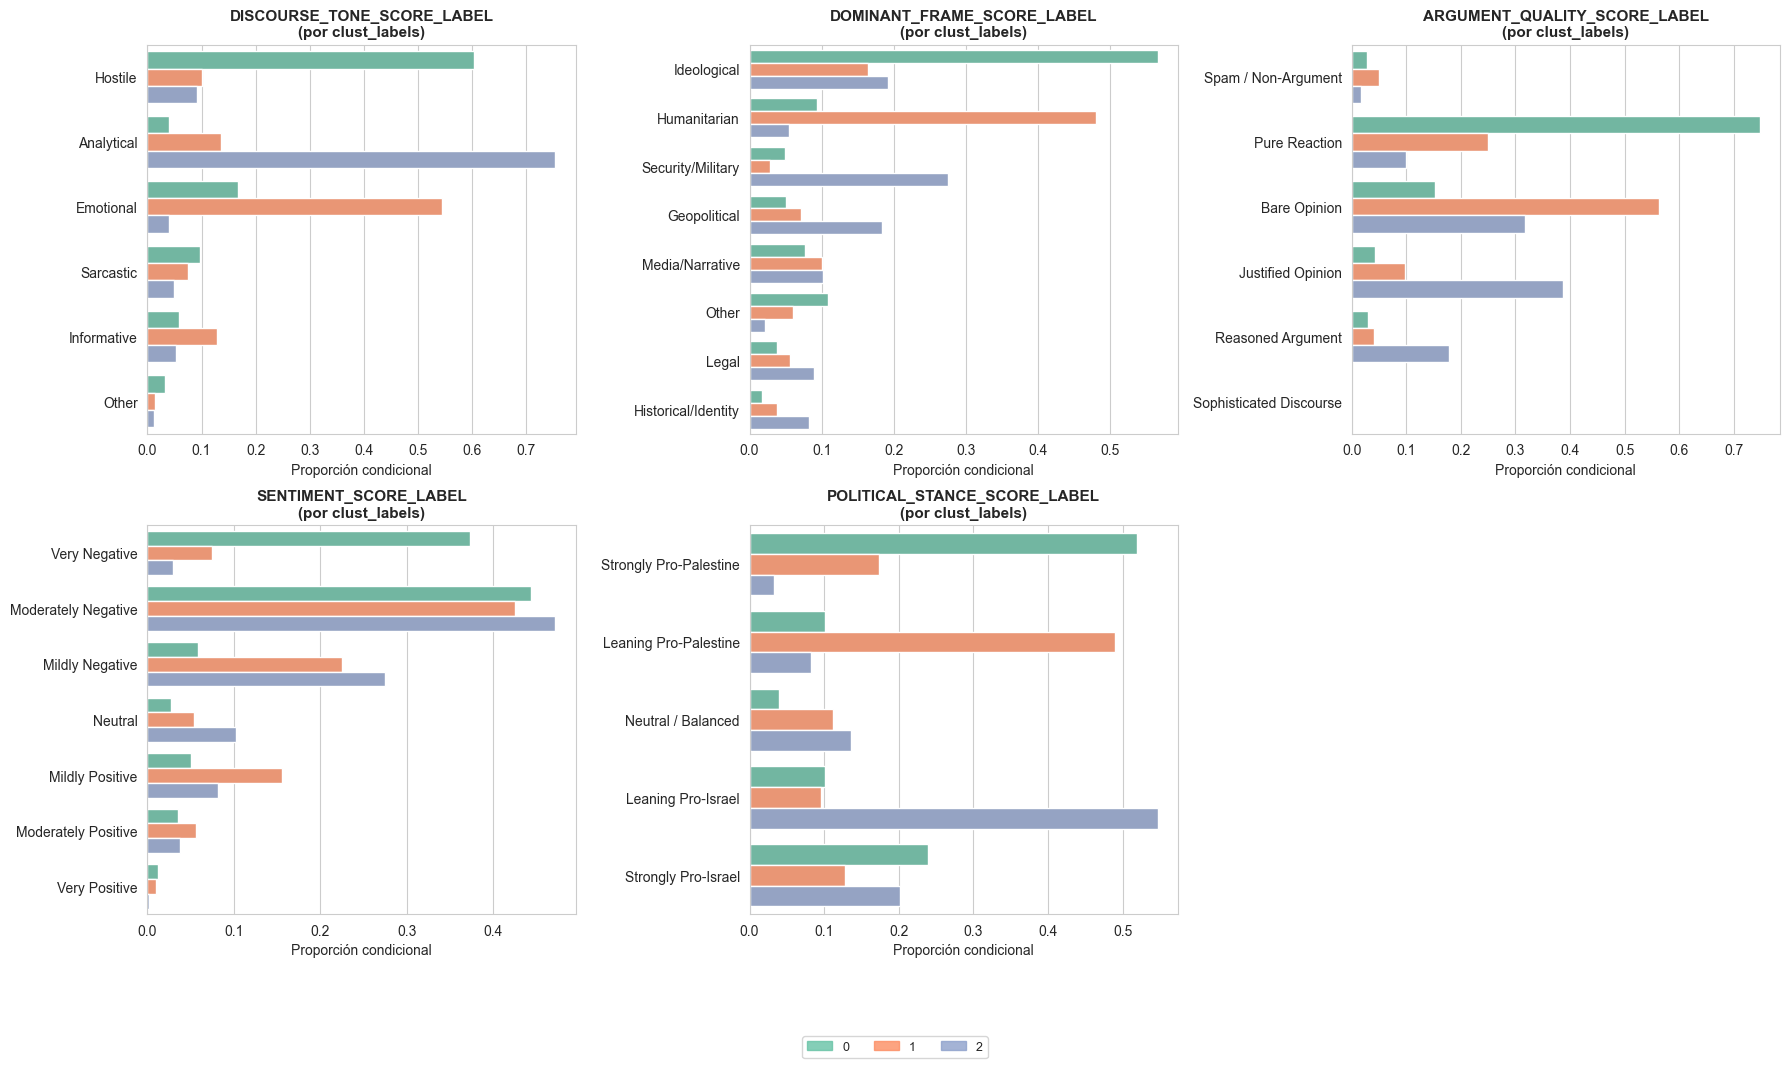

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""If Pro-Palestine “empathy” leads to more deaths, what are we actually supporting?""","""This is an honest to god question as I genuinely do not understand how people can look at this conflict and conclude that Israel is “the bad guy.” The war itself is tragic and nobody with a sense of humanity celebrates it, but when you look at the last 70 or 75 years, what is almost astounding to me, is how long it took to reach this point. Given the constant attacks, the explicit genocidal rhetoric, and the pattern of provocation since 1947, the idea that Israel is acting out of pure malice rather than accumulated context feels completely detached from reality. What makes this even stranger is that the conflict did not unfold in a vacuum. It sits inside a much larger regional pattern, the near total homogenisation of the MENA region over the last century. Armenians were exterminated in the Armenian Genocide, Assyrians slaughtered in the Assyrian Genocide, Greeks expelled, Jews driven out of Iraq, Egypt, Yemen and Syria, Christian communities shrinking everywhere from Lebanon to Gaza.…","""Israel IS THE BAD GUY. Why you ask? 70,000 killed by Israel in response to an attack. Lands stolen and continue to be stolen from Palestinians in the West Bank. Simple.""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Why are Palestine supporters so insufferable?""","""I want to start out by saying I oppose a significant amount of the things Israel is doing in Palestine, and think that Netanyahu is undisputedly a war criminal, and deserves jail. That being said it seems like the people supporting Palestine get more extremist every day. For example celebrating the October 7th attacks as some kind of heroic stand against tyranny. When in reality it was one of the deadliest terrorist attacks in history, and the catalyst for this entire war. If Hamas had never attacked on October 7th, there would be tens of thousands of Palestinians still alive. Another example is attacking anyone who even slightly supports Israel. AOC one of the most progressive people in Congress, and one of the biggest critics of Israel, just got death threats and her office vandalized for voting in favor of continuing to support the Iron Dome system in Israel, which is purely defensive. Or thinking that Biden/Harris would have been nothing different than Trump in their policy on Is…","""The more extreme Israel’s genocide the more extreme the opposition is going to be""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Israel is mostly in the right in the Israel-Palestine conflict""","""There were mass Arab pogroms of Jews before 1948 in the British mandate of Palestine, and tensions were only escalating. A single, independent state where Jews and Arabs lived together was never realistic. In 1948, at the time of independence, Israel was merely two tiny, disconnected pieces of land in the mandate of Palestine along the coast and towards the south in the Negev desert. Nevertheless, Israel accepted the partition and Jewish leaders like David Ben-Gurion and others called on the Arabs living there, 45% of the population at the time, to stay, promising equal rights. The *Declaration of the Establishment of the State of Israel* itself states: >""We appeal... to the Arab inhabitants of the State of Israel to return to the ways of peace and play their part in the development of the State, on the basis of full and equal citizenship and due representation in all its provisional and permanent institutions."" What did the Arabs do? The Arabs of Palestine rejected the partition, a…","""This is a hot, steaming pile of cope lol. If anyone looks up video of what is happening in Gaza, of what has 

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""The flaws of genocide reports on Israel and a challenge to those who agree with them""","""It has almost become customary to appeal to authority when it comes to genocide allegations against Israel. I see increasing number of people committing this fallacy, throwing in a link or two, referencing “experts”, NGO-s or lately the recent UN commission report, then dropping the mic as they have won the debate. But aside from the fact that they’re committing a logical fallacy, the problem with this is that all of these reports (which I am aware of) and “expert opinions” suffer from the exact same flaws, namely that they do not engage with significant counter-factuals and pretend as though Israel is shadow-boxing in Gaza. There are other problems too (such as the relentless misinformation of quotes coming from Israeli officials such as Gallant, Netanyahu or Herzog) but i think the above flaws are the most obvious. Hamas and their military conduct is virtually non-existent, even though war is a reciprocal activity. You simply can’t judge one party’s conduct without the context prov…","""tbh at this point not trying to debate with genocide deniers, it’s so tired and sad that you can’t see it for yourself. but hell, at least without a report I’ll give just one example. Basic math is, if you warn Gazans where to go, so that you can target Hamas, but then when you target Hamas, and then allege that they’re using human shields, you are knowingly targeting civilians, considering you are telling them where to go and they’re still dying. idk. If you can’t see why Israel is losing a lot more than they’re gaining with this mess no one can really help you see that. Cheers tho, appreciate the post""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Moderately Negative""","""Leaning Pro-Palestine"""
"""DISMANTLING THE MYTH OF THE “GENOCIDE” IN GAZA""","""Hey salami, stop seeking fame by provoking me with your Judeophobic lies and justifying antisemitic attacks. There is no such genocide except in the antisemitic and weak minds like yours. DISMANTLING THE MYTH OF THE “GENOCIDE” IN GAZA In the last two years, the international narrative about the war in Gaza has been permeated by an accusation as extreme as it is false: that Israel would be carrying out a genocide. The term is not trivial. The UN Convention defines genocide as acts perpetrated “with the intent to destroy, in whole or in part, a national, ethnic, racial or religious group, as such.” In other words: it requires intent to exterminate. And that, plain and simple, does not exist in Israel's case. The undesirable and painful civilian casualties within a war do not fall under that definition. Israel never declared, nor executed, a campaign of annihilation against the Palestinians. On the contrary: all its wars were defensive, initiated as a response to massive attacks agains…","""Natural deaths.... As in due to lack of health care. Then I remember watching videos of IDF going around to all the hospital equipment and destorying it with their rifle butts. Genocide or not, Israel is doing sadistic stuff in Gaza. Permanent stain on Israel reputation. Whats the point of this level of destruction? It's just making people hate Israel more, thus easy recruiting for Hamas, extremely counterproductive for Israels long term safety.""","""Emotional""","""Humanitarian""","""Bare Opinion""","""Moderately Negative""","""Leaning Pro-Israel"""
"""The Gaza war was obviously not genocide.""","""I want to discuss this line of argument. I am in agreement with the statement and I think it is a logical conclusion of asking a simple question. If we assume good intentions from Israel then in the conditions present in this war how much death and destruction would you expect? And the answer, I am personally qu

--------------------------------------------------
Medoid and KNN for Cluster 2:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""If Pro-Palestine “empathy” leads to more deaths, what are we actually supporting?""","""This is an honest to god question as I genuinely do not understand how people can look at this conflict and conclude that Israel is “the bad guy.” The war itself is tragic and nobody with a sense of humanity celebrates it, but when you look at the last 70 or 75 years, what is almost astounding to me, is how long it took to reach this point. Given the constant attacks, the explicit genocidal rhetoric, and the pattern of provocation since 1947, the idea that Israel is acting out of pure malice rather than accumulated context feels completely detached from reality. What makes this even stranger is that the conflict did not unfold in a vacuum. It sits inside a much larger regional pattern, the near total homogenisation of the MENA region over the last century. Armenians were exterminated in the Armenian Genocide, Assyrians slaughtered in the Assyrian Genocide, Greeks expelled, Jews driven out of Iraq, Egypt, Yemen and Syria, Christian communities shrinking everywhere from Lebanon to Gaza.…","""I agree, which is why while I say that I’m pro-Palestine at this point of the war because I think Israel needs to be restrained, so there is an incentive to end the war, I’ll never be an anti-Zionist. I think the fears that Israeli Jews have against their Arab neighbors is completely justified. They are fighting a multi-front war against terrorist groups who want to destroy the Jewish state. If Israel was no longer majority Jewish that could potentially spell disaster as Palestinians might vote for a “right to return” and do a massive ethnic cleansing of Jews from their homes. While every death is a tragedy, I’m less focused on that and more focused on actually completely the mission objective of driving out Hamas and getting the hostages back home. The problem with the current government is they seem to be less interested in that and more interested in land acquisition. There needs to be a deradicalization effort on both sides. While leftists might say they are consistent and not …","""Analytical""","""Security/Military""","""Justified Opinion""","""Mildly Negative""","""Leaning Pro-Israel"""
"""It's insane that the idea of exterminating 8 million Jews is so normalized among leftists today""","""TL:DR - Leftists constantly define themselves as 'anti zionists', which means that they want Israel destroyed, and it's clear that if Israel is destroyed, the countries surrounding it will kill every single Jewish person in it Everywhere I go to this site for a decade now whenever Israel comes into the discussion you will A LOT of people casually saying ""I am anti Zionist"", which, **by definition**, means, the destruction of Israel For 2000 years this was the definition of Zionism >Zionism is the belief in the Jewish people’s right to self-determination in our ancestral homeland of Israel. It affirms that Jews, like all peoples, have the right to live in safety, dignity, and sovereignty in a nation of their own. [https://jewishcenterforjustice.org/what-is-zionism-six-things-to-know/](https://jewishcenterforjustice.org/what-is-zionism-six-things-to-know/) The Anti of that idea, is that the Jews won't have a country of their own, and if they do have a country, then it needs to be…","""Not wanting to fight Israel's wars is not the same as wanting genocide of Jews. I'm not a leftist but I also don't want us involved in random crap, and I also don't ""support"" Palestine. The most we should do is maybe sell weapons. Israel can defend itself. I think Israel is a sovereign state and that it's sandwiched between bad neighbors, but that's not our responsibility. Also, the IDF is not to be fucked with. It's not some inexperienced backwater raggedy force. They have a lot o

SampleDistClustering-KMedoids-PAM - k=4


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


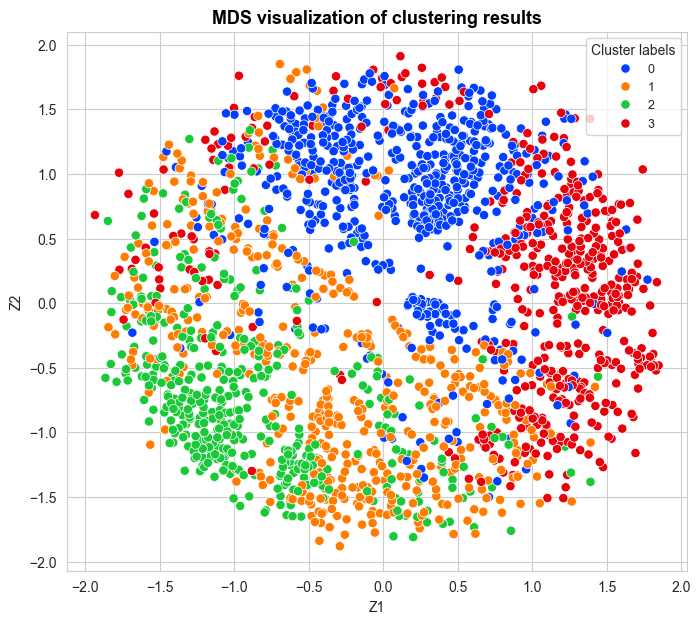

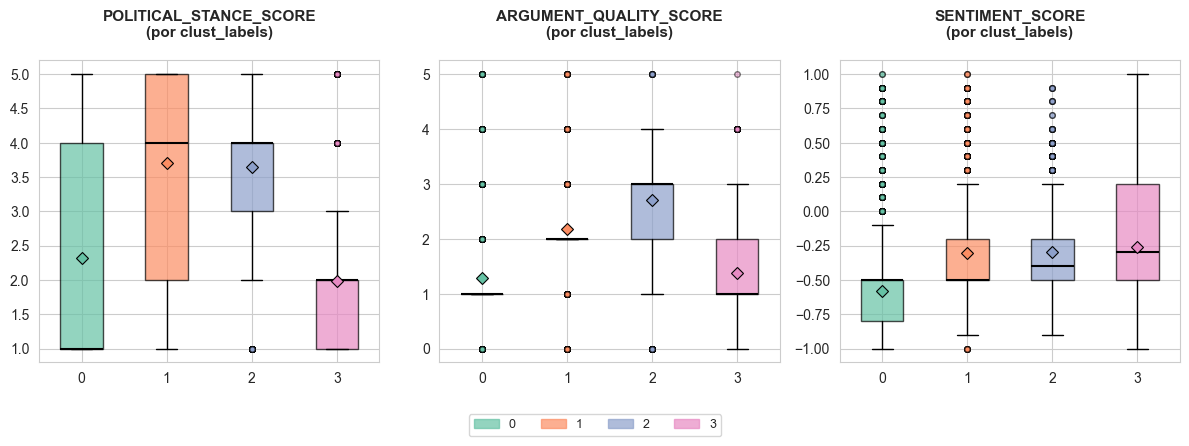

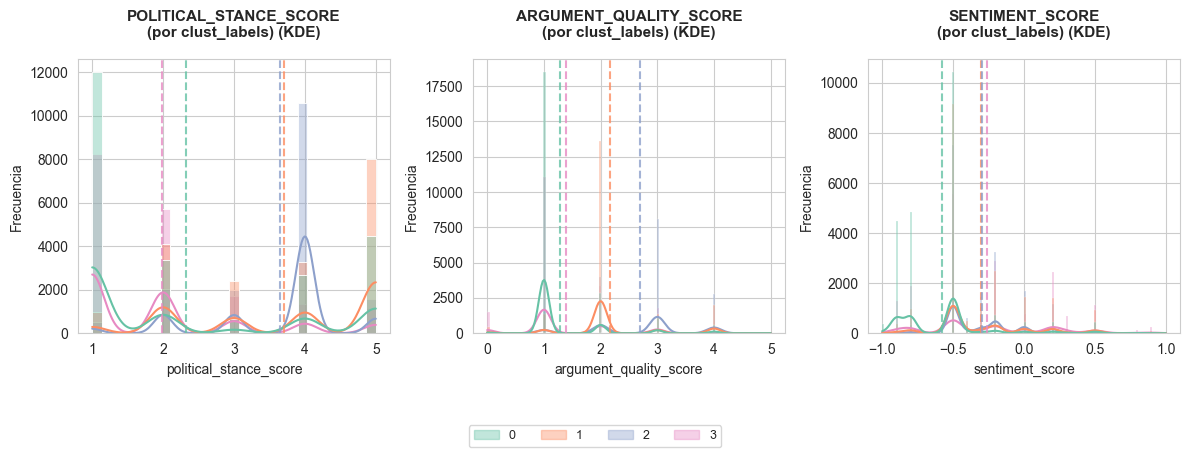

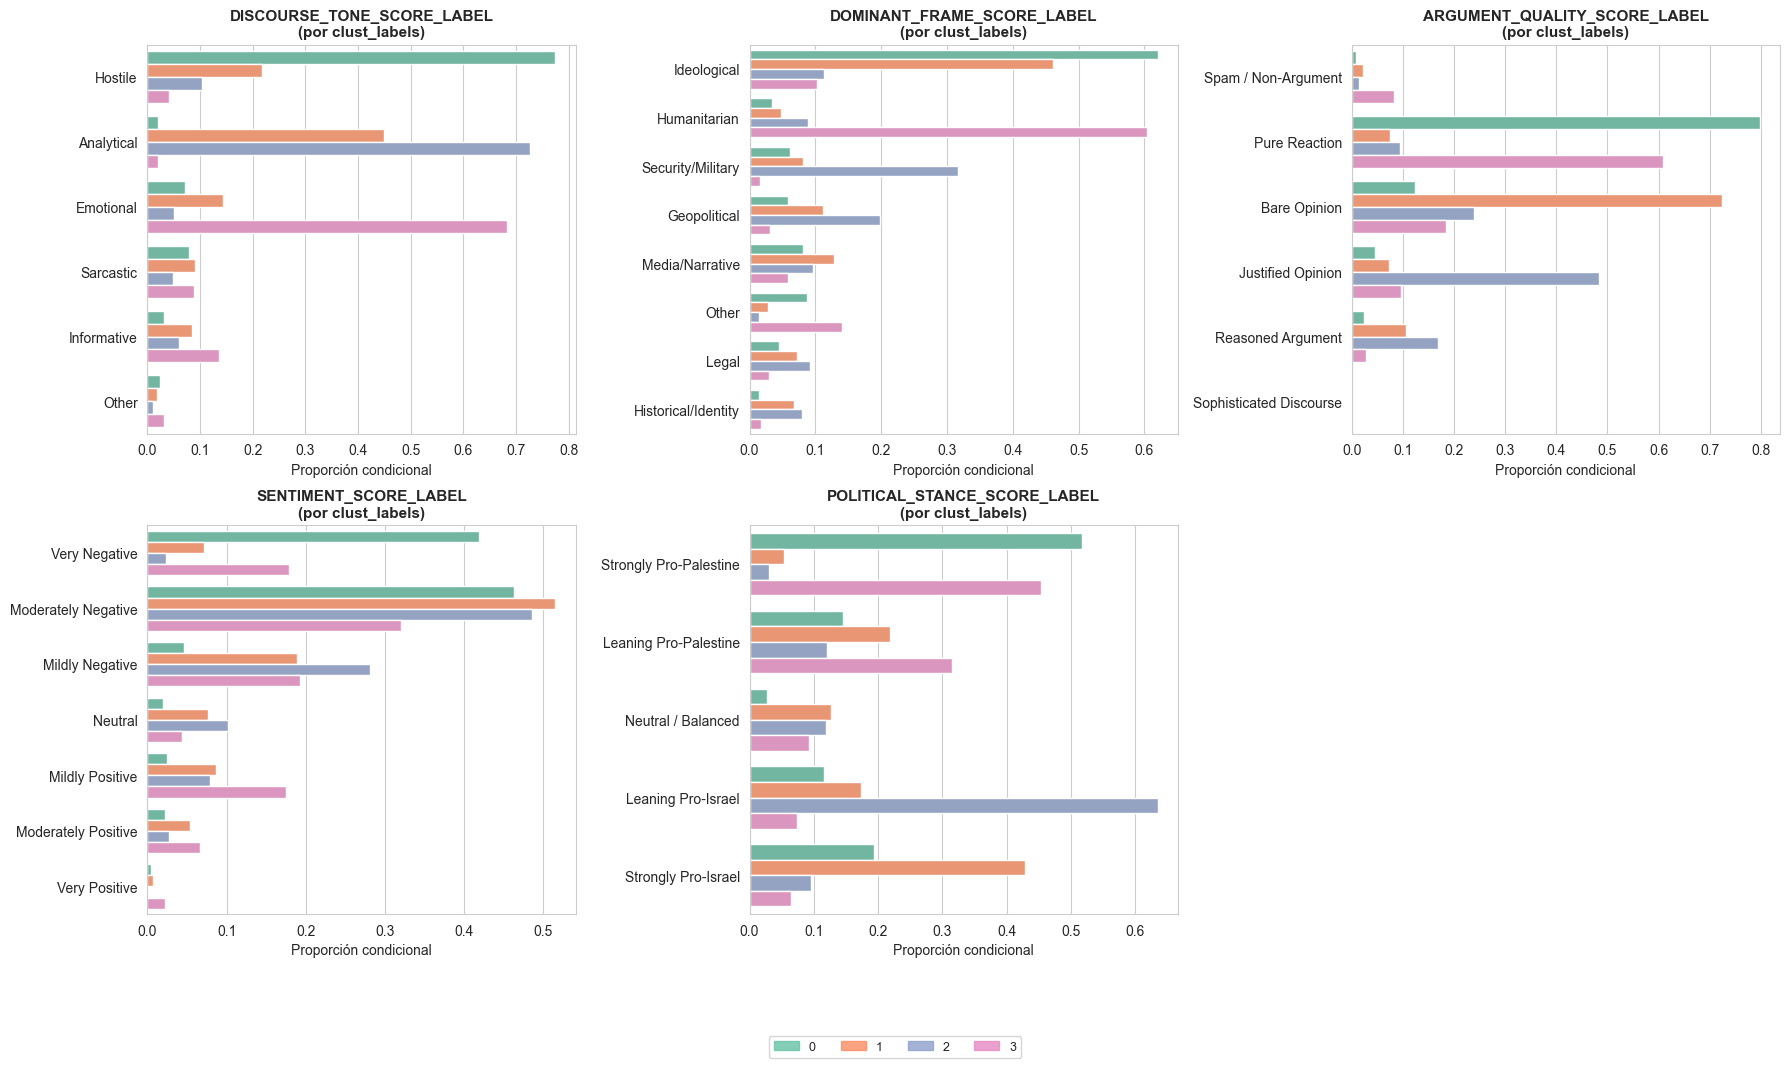

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""If Pro-Palestine “empathy” leads to more deaths, what are we actually supporting?""","""This is an honest to god question as I genuinely do not understand how people can look at this conflict and conclude that Israel is “the bad guy.” The war itself is tragic and nobody with a sense of humanity celebrates it, but when you look at the last 70 or 75 years, what is almost astounding to me, is how long it took to reach this point. Given the constant attacks, the explicit genocidal rhetoric, and the pattern of provocation since 1947, the idea that Israel is acting out of pure malice rather than accumulated context feels completely detached from reality. What makes this even stranger is that the conflict did not unfold in a vacuum. It sits inside a much larger regional pattern, the near total homogenisation of the MENA region over the last century. Armenians were exterminated in the Armenian Genocide, Assyrians slaughtered in the Assyrian Genocide, Greeks expelled, Jews driven out of Iraq, Egypt, Yemen and Syria, Christian communities shrinking everywhere from Lebanon to Gaza.…","""Israel IS THE BAD GUY. Why you ask? 70,000 killed by Israel in response to an attack. Lands stolen and continue to be stolen from Palestinians in the West Bank. Simple.""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Why are Palestine supporters so insufferable?""","""I want to start out by saying I oppose a significant amount of the things Israel is doing in Palestine, and think that Netanyahu is undisputedly a war criminal, and deserves jail. That being said it seems like the people supporting Palestine get more extremist every day. For example celebrating the October 7th attacks as some kind of heroic stand against tyranny. When in reality it was one of the deadliest terrorist attacks in history, and the catalyst for this entire war. If Hamas had never attacked on October 7th, there would be tens of thousands of Palestinians still alive. Another example is attacking anyone who even slightly supports Israel. AOC one of the most progressive people in Congress, and one of the biggest critics of Israel, just got death threats and her office vandalized for voting in favor of continuing to support the Iron Dome system in Israel, which is purely defensive. Or thinking that Biden/Harris would have been nothing different than Trump in their policy on Is…","""The more extreme Israel’s genocide the more extreme the opposition is going to be""","""Hostile""","""Ideological""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Israel is mostly in the right in the Israel-Palestine conflict""","""There were mass Arab pogroms of Jews before 1948 in the British mandate of Palestine, and tensions were only escalating. A single, independent state where Jews and Arabs lived together was never realistic. In 1948, at the time of independence, Israel was merely two tiny, disconnected pieces of land in the mandate of Palestine along the coast and towards the south in the Negev desert. Nevertheless, Israel accepted the partition and Jewish leaders like David Ben-Gurion and others called on the Arabs living there, 45% of the population at the time, to stay, promising equal rights. The *Declaration of the Establishment of the State of Israel* itself states: >""We appeal... to the Arab inhabitants of the State of Israel to return to the ways of peace and play their part in the development of the State, on the basis of full and equal citizenship and due representation in all its provisional and permanent institutions."" What did the Arabs do? The Arabs of Palestine rejected the partition, a…","""This is a hot, steaming pile of cope lol. If anyone looks up video of what is happening in Gaza, of what has 

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""Saw someone on Reddit say “Israel is genuinely a sociopathic society” and I am disgusted""","""I was lurking on a Reddit thread and saw someone say that “Israel is genuinely a sociopathic society.” It hit me like a punch to the gut. Calling an entire society sociopathic? This is blatant antisemitism. As if there’s not a single Israeli citizen who doesn’t protest the current government? As if there’s no dissent, no nuance, no humanity? What they’re saying is “all Israelis are sociopaths “ which then means that all Jews are sociopaths. I’m Jewish. I’ve always considered myself on the left, but I’ve been feeling increasingly alienated. It’s exhausting to constantly see dehumanizing rhetoric, to watch people who claim to care about justice repeat antisemitic talking points, and to be told directly or indirectly that my life, my people, my pain don’t matter. I’m so sick and tired of antisemitism becoming normal. ""","""Most of them are misinformed about the Israel/Palestine conflict. They believe Palestinians are indigenous to the area. They believe Jews stole the land that is now Israel. They believe the U.S. armed Israel in her war for independence. They believe Israel is a theocracy. They believe the West Bank is on the west side of Palestine, and that's why it's called the ""west bank."" They believe that Israel was gifted to the Jews by the U.N. They lie about Israel and Palestinians for the same reason conservatives lie to defend Trump and the GOP. They lie because they can't defend their opinions using facts and logic.""","""Analytical""","""Ideological""","""Bare Opinion""","""Mildly Negative""","""Strongly Pro-Israel"""
"""Feeling really disturbed at the current Israel discourse on Reddit""","""I’m sure many of you have already gotten to this point way before the most recent incident with Israel and Iran but I’ve just been gobsmacked at how the overwhelming majority of Reddit is just straight up pro Iran getting nukes/anti Israel and gleeful in the paradigm that “Israel deserved it and anything that happens to them” based off the issues in Gaza. I feel like I’m taking crazy pills where no one is aware of the entire history of this conflict and why Israel operates the way it does with it’s preventative attacks. I can’t tell if it’s a genuine hatred of Israel, an ignorance of history, remnants of all the anti Israel misinformation and brainwashing shoved at Gen Z through avenues such as TikTok. I go over to the conservative subreddit and somehow they are the only ones thinking logically about this situation amidst all their lunacy. I feel so lost as a liberal jew Zionist. I can’t tell what’s up or down anymore, it really feels like this site is starting to go down the deep end.…","""It’s just basic Jew hatred, same as what our grandparents faced. Just slightly repackaged. Why do I think this? Because in their minds children in Gaza and Iran are innocent, yet Jewish children in Israel are somehow tainted at birth. Collective punishment is wrong, except for when it comes to Jews and Israelis. They condemn the KKK yet repeat their tropes (“Zio”). Etc. There’s no logic to it. It’s just pure Jew hatred. ""","""Hostile""","""Ideological""","""Bare Opinion""","""Very Negative""","""Strongly Pro-Israel"""
"""Feeling really disturbed at the current Israel discourse on Reddit""","""I’m sure many of you have already gotten to this point way before the most recent incident with Israel and Iran but I’ve just been gobsmacked at how the overwhelming majority of Reddit is just straight up pro Iran getting nukes/anti Israel and gleeful in the paradigm that “Israel deserved it and anything that happens to them” based off the issues in Gaza. I feel like I’m taking crazy pills where no one is aware of the entire history of this conflict and why 

--------------------------------------------------
Medoid and KNN for Cluster 2:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""If Pro-Palestine “empathy” leads to more deaths, what are we actually supporting?""","""This is an honest to god question as I genuinely do not understand how people can look at this conflict and conclude that Israel is “the bad guy.” The war itself is tragic and nobody with a sense of humanity celebrates it, but when you look at the last 70 or 75 years, what is almost astounding to me, is how long it took to reach this point. Given the constant attacks, the explicit genocidal rhetoric, and the pattern of provocation since 1947, the idea that Israel is acting out of pure malice rather than accumulated context feels completely detached from reality. What makes this even stranger is that the conflict did not unfold in a vacuum. It sits inside a much larger regional pattern, the near total homogenisation of the MENA region over the last century. Armenians were exterminated in the Armenian Genocide, Assyrians slaughtered in the Assyrian Genocide, Greeks expelled, Jews driven out of Iraq, Egypt, Yemen and Syria, Christian communities shrinking everywhere from Lebanon to Gaza.…","""I agree, which is why while I say that I’m pro-Palestine at this point of the war because I think Israel needs to be restrained, so there is an incentive to end the war, I’ll never be an anti-Zionist. I think the fears that Israeli Jews have against their Arab neighbors is completely justified. They are fighting a multi-front war against terrorist groups who want to destroy the Jewish state. If Israel was no longer majority Jewish that could potentially spell disaster as Palestinians might vote for a “right to return” and do a massive ethnic cleansing of Jews from their homes. While every death is a tragedy, I’m less focused on that and more focused on actually completely the mission objective of driving out Hamas and getting the hostages back home. The problem with the current government is they seem to be less interested in that and more interested in land acquisition. There needs to be a deradicalization effort on both sides. While leftists might say they are consistent and not …","""Analytical""","""Security/Military""","""Justified Opinion""","""Mildly Negative""","""Leaning Pro-Israel"""
"""It's insane that the idea of exterminating 8 million Jews is so normalized among leftists today""","""TL:DR - Leftists constantly define themselves as 'anti zionists', which means that they want Israel destroyed, and it's clear that if Israel is destroyed, the countries surrounding it will kill every single Jewish person in it Everywhere I go to this site for a decade now whenever Israel comes into the discussion you will A LOT of people casually saying ""I am anti Zionist"", which, **by definition**, means, the destruction of Israel For 2000 years this was the definition of Zionism >Zionism is the belief in the Jewish people’s right to self-determination in our ancestral homeland of Israel. It affirms that Jews, like all peoples, have the right to live in safety, dignity, and sovereignty in a nation of their own. [https://jewishcenterforjustice.org/what-is-zionism-six-things-to-know/](https://jewishcenterforjustice.org/what-is-zionism-six-things-to-know/) The Anti of that idea, is that the Jews won't have a country of their own, and if they do have a country, then it needs to be…","""Not wanting to fight Israel's wars is not the same as wanting genocide of Jews. I'm not a leftist but I also don't want us involved in random crap, and I also don't ""support"" Palestine. The most we should do is maybe sell weapons. Israel can defend itself. I think Israel is a sovereign state and that it's sandwiched between bad neighbors, but that's not our responsibility. Also, the IDF is not to be fucked with. It's not some inexperienced backwater raggedy force. They have a lot o

--------------------------------------------------
Medoid and KNN for Cluster 3:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label
str,str,str,str,str,str,str,str
"""The most disturbing story you'll hear today: Israel killed the family of a Gaza surgeon, Dr. Khalid, forcing him to watch it live.""","""Source in the comments. ""","""This is the shit their doing that we know about. Imagine what theure doing that we don't know about.""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Moderately Negative""","""Strongly Pro-Palestine"""
"""Israel used US-supplied thermal Weapons that burn at 3,500C to Murder thousands of Palestinians, the people evaporated.""","""""","""They no longer want bodies to be the only witness to their atrocities, what is happening? How can we let this go on?""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Moderately Negative""","""Strongly Pro-Palestine"""
"""This is how a normal day in Gaza looks like""","""""","""Israel bombs and murders people in brutally violent ways, then tries to justify it afterwards by claiming they were ‘acting.’ It’s sick and evil.""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""The IDF has been carrying out this depraved stunt to lure and kill Palestinians since April last year...""","""""","""At this point they are trying to be the most evil people on earth. I mean the abuse they are trying to exert on Palestinians has passed the holocaust in cruelty. They are playing with Gaza’s before they kill them and it’s all for their own pleasure. And this only based on what we know, imagine what we will learn when this is all over.""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""The Gaza holocaust""","""""","""They're purposefully AIMING for children https://youtu.be/U5k_Sw_UNpo?si=JXtUCDIyAsWiAwHX The plan for Isreal is to murder the children in order to prevent the Gazans from reproducing. Trully despicable""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""I know that there are some good people in Isrl who are fighting against the oppression. The rest...""","""""","""I never really understood this, even till now. How can they let children die from bombs and let them starve to death? My only explanation is that they are just pure evil. Truly Epstein's people. ""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""
"""Israel is killing 100 Palestinians every day and the mainstream media barely reports it. They’ve normalized daily massacres.""","""""","""Plus there are a bunch of hasbaraists right now reporting that gazans are soooo thankful for food that they are been given by the US, as if they haven't been bombed and starved and burying their children because of them. I really had it with humans.""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine"""


In [23]:
for n_clusters in N_CLUSTERS_LIST:

    get_SampleDistClustering_results(n_clusters, processed_data, quant_cols, binary_cols, multiclass_cols, QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER)

# Time: 30 mins

## Clustering III: Data - Embeddings

KMeans - k=2


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


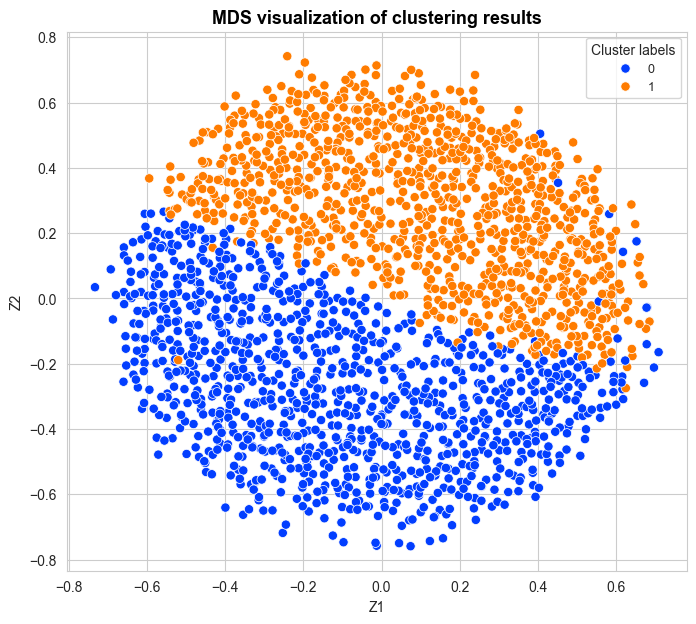

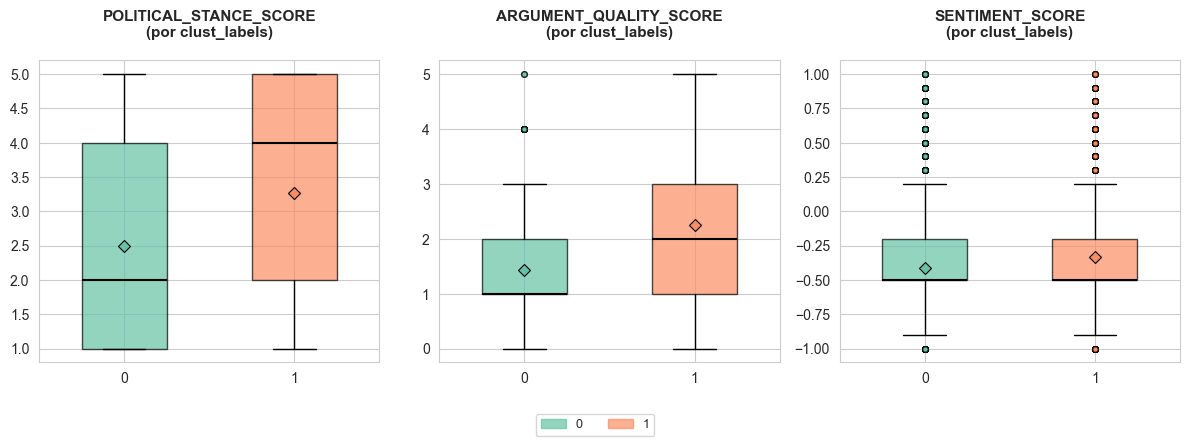

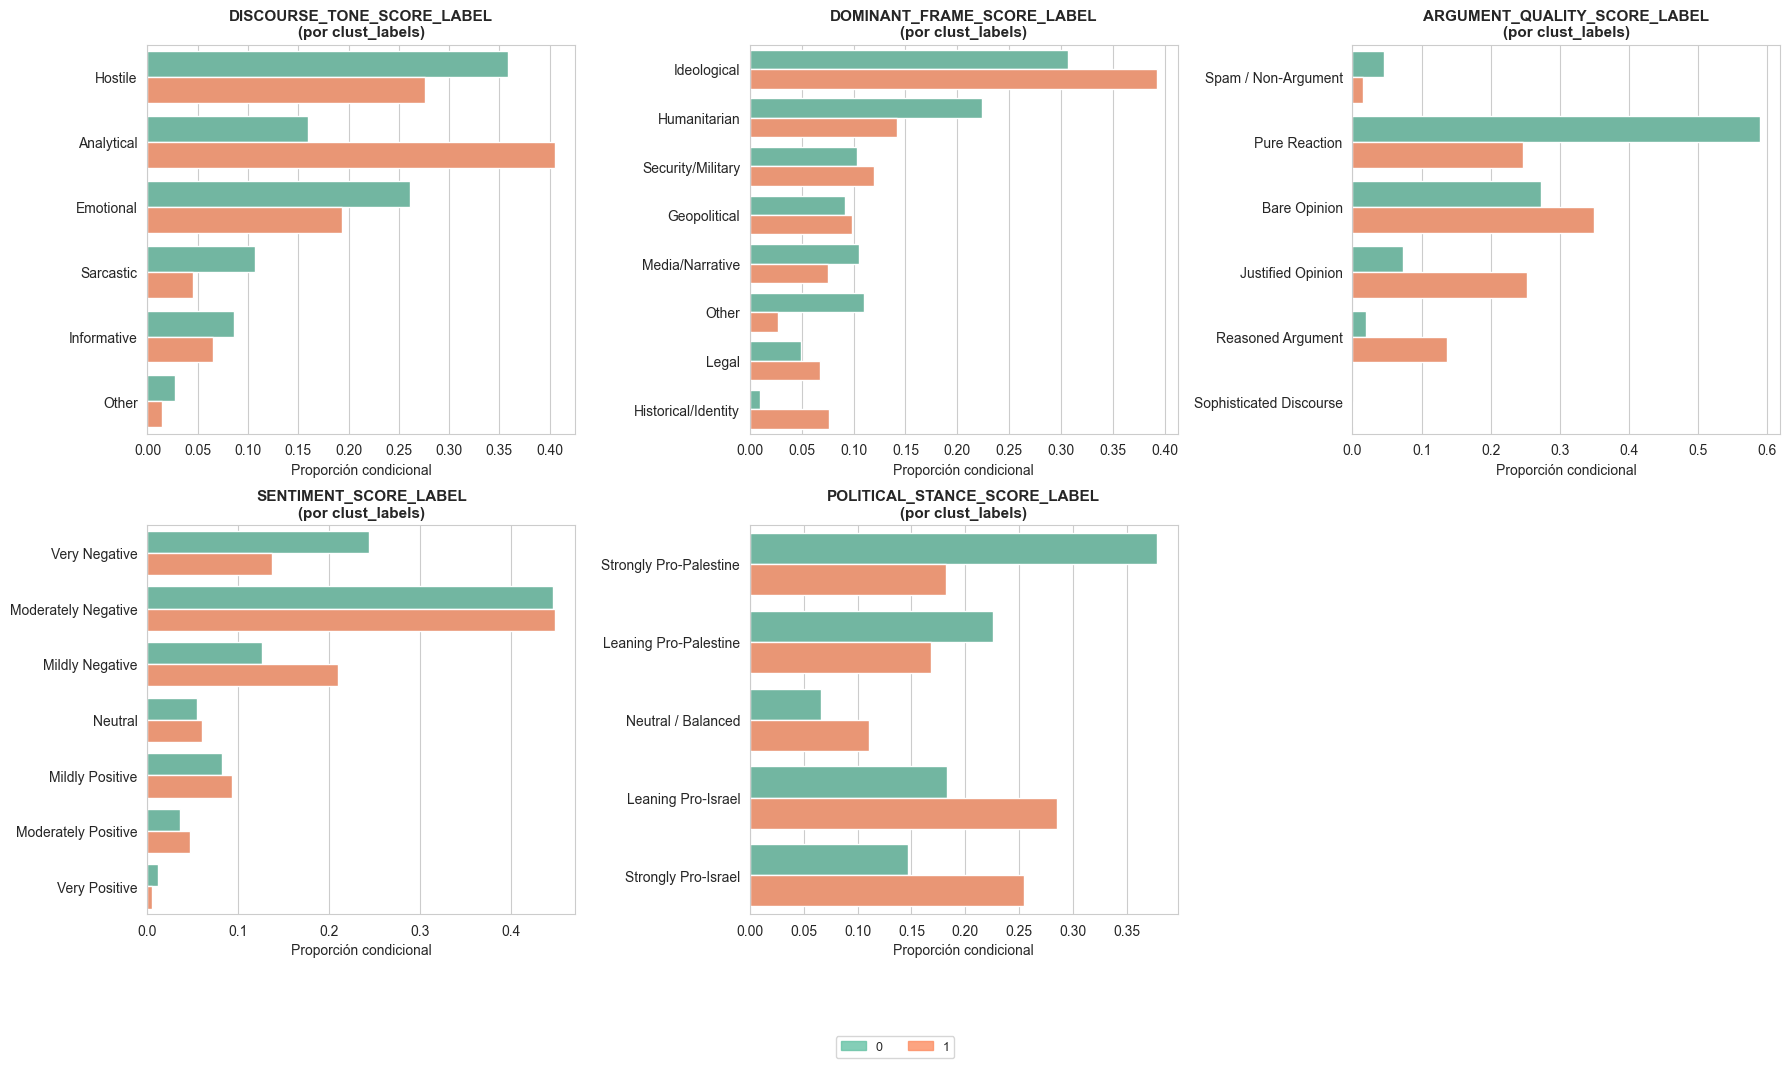

KMeans - k=3


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


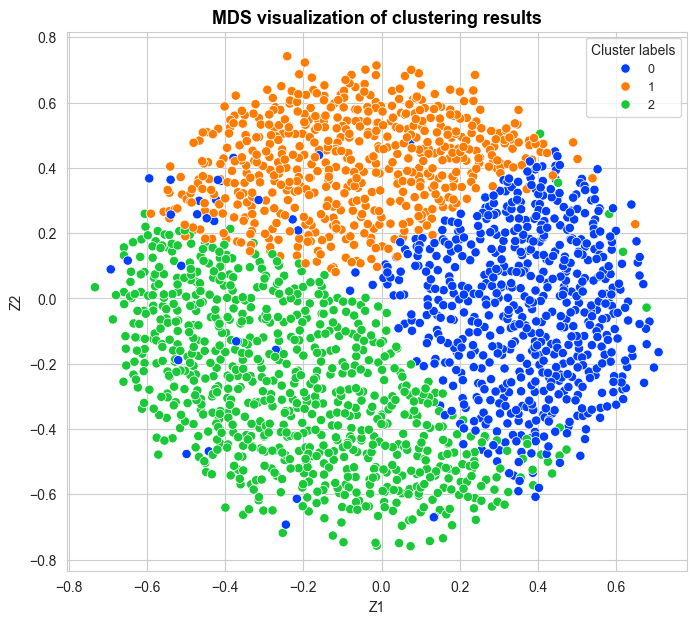

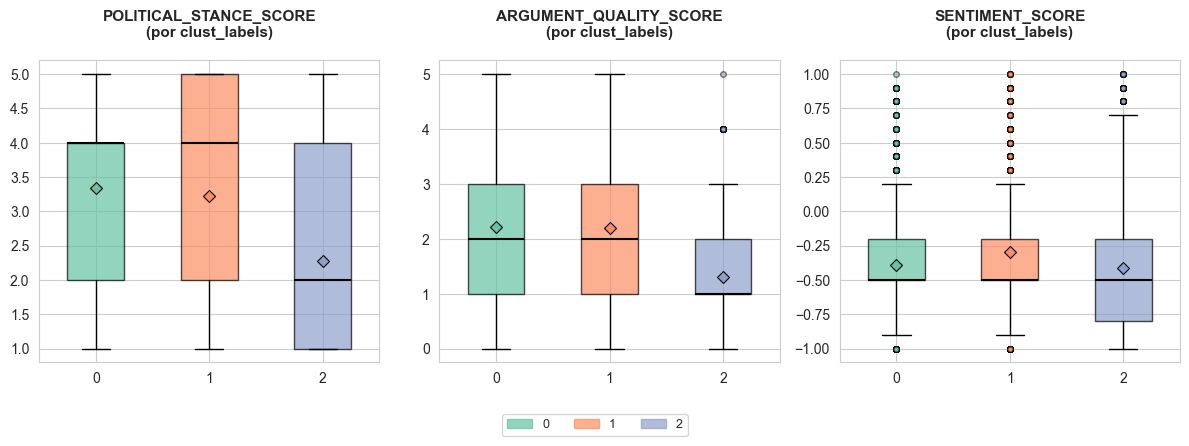

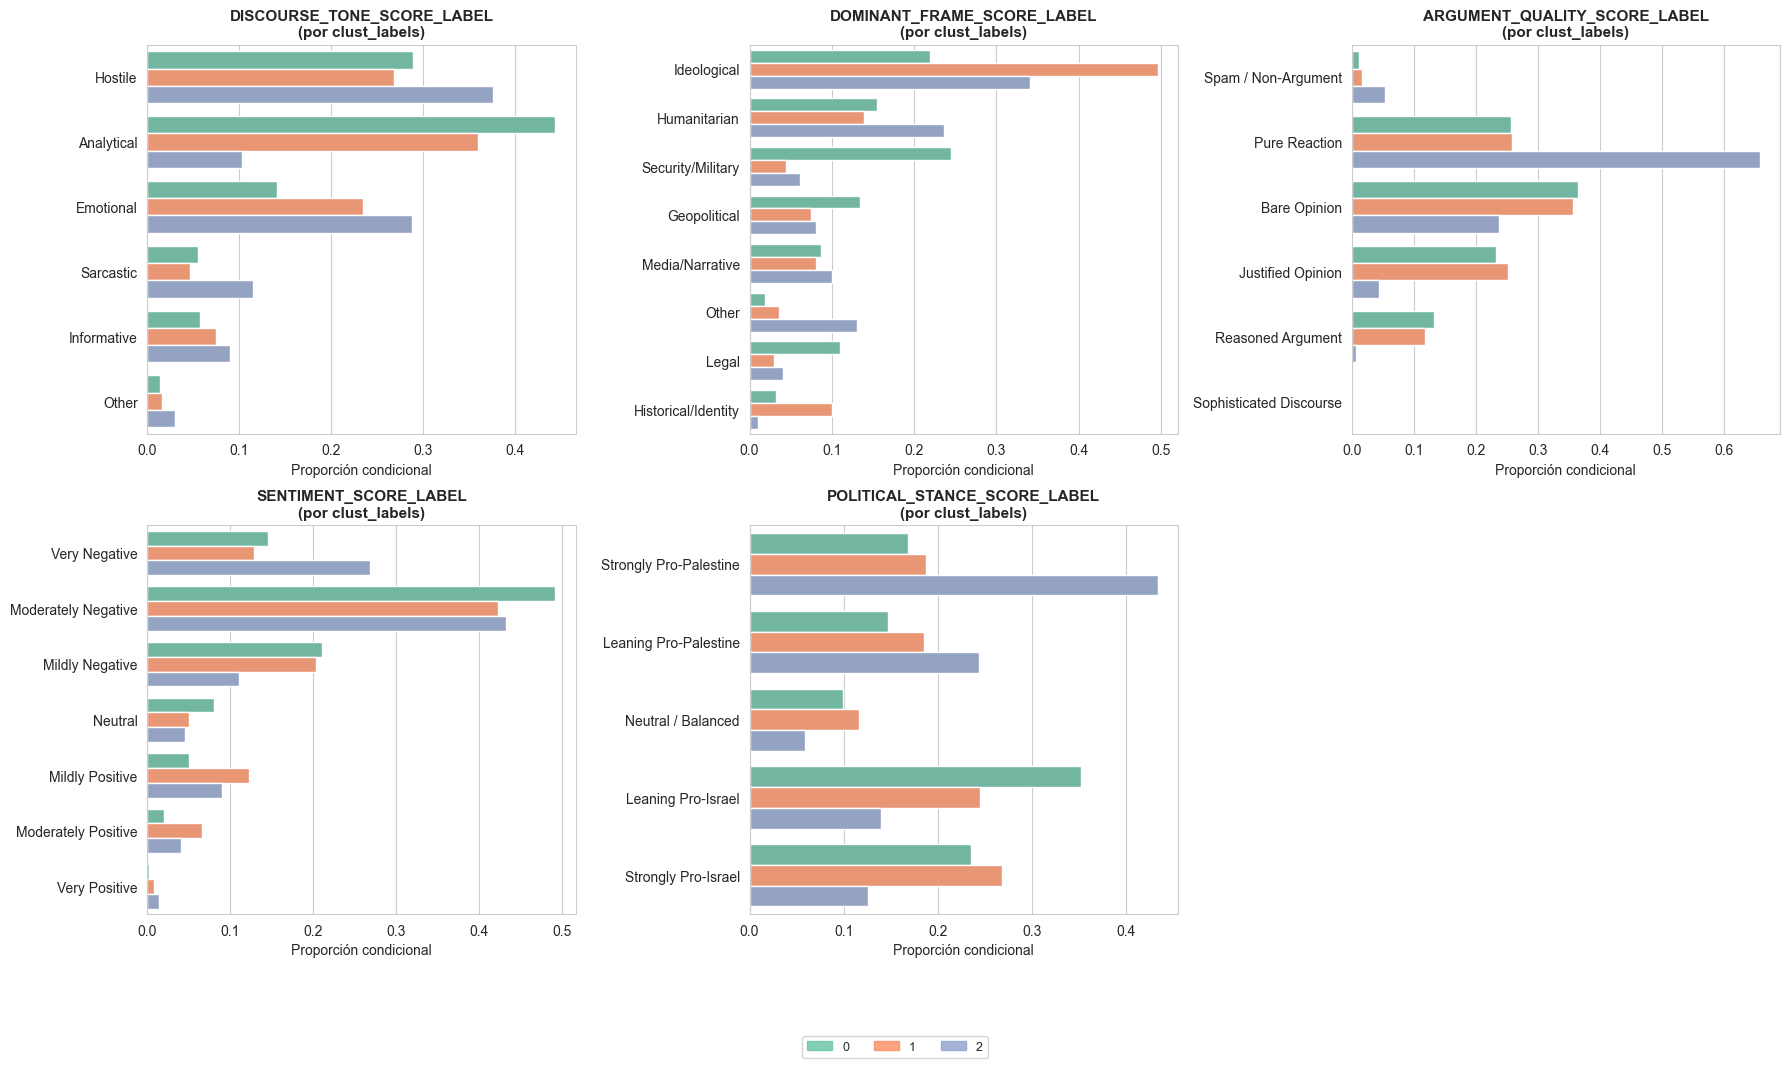

KMeans - k=4


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


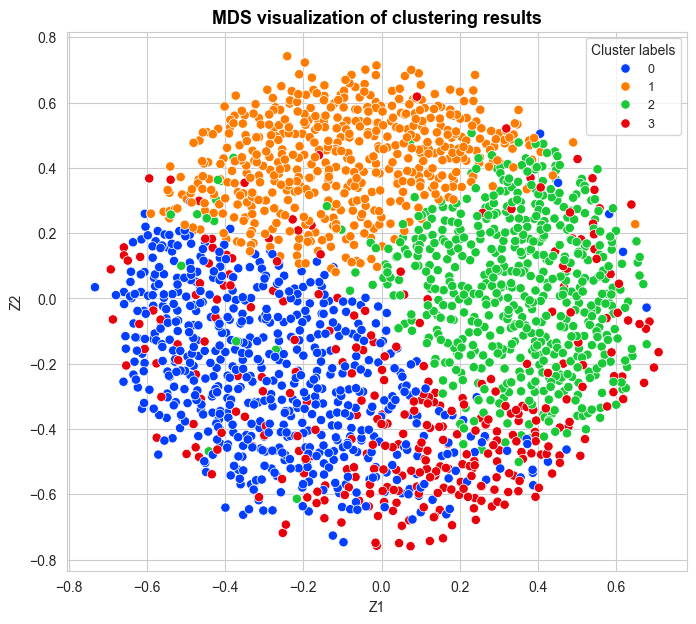

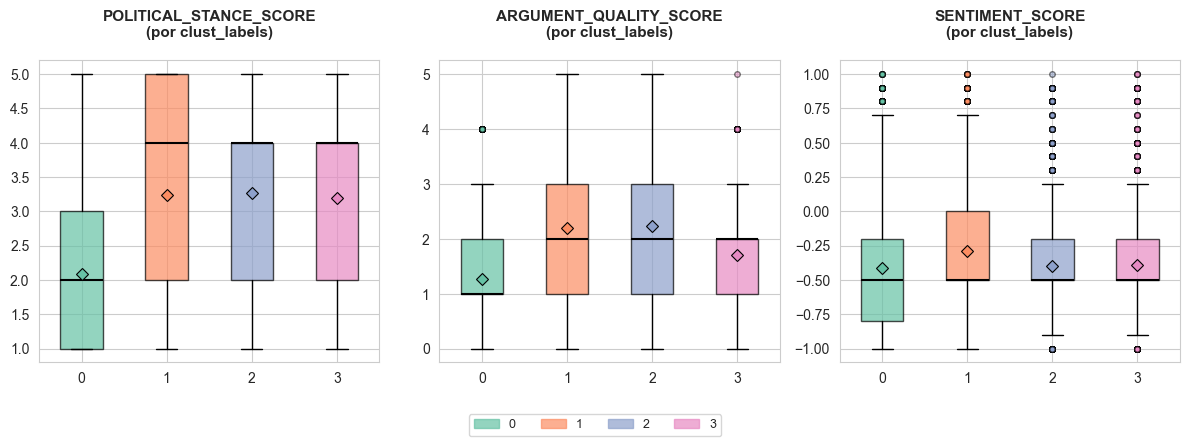

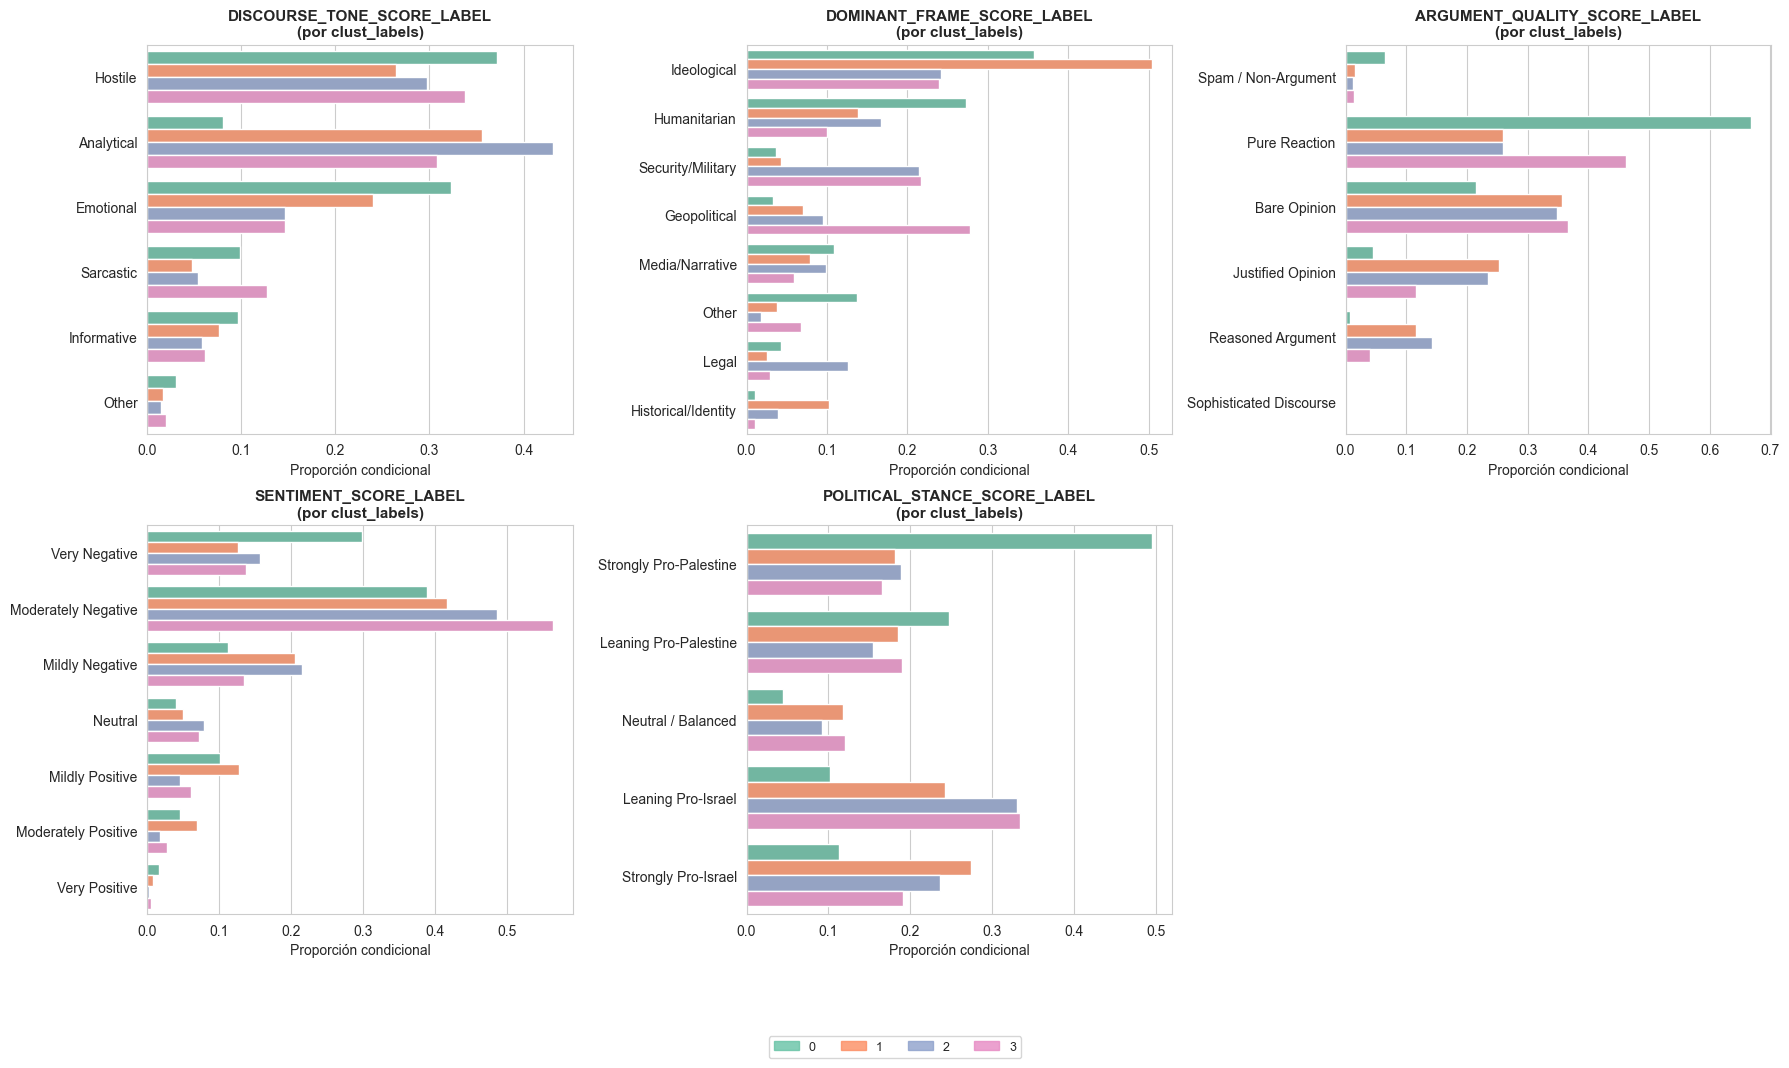

In [31]:
X = processed_data[embeddings_cols]

for n_clusters in N_CLUSTERS_LIST:

    get_KMeans_results(n_clusters, processed_data, X, QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER)

# Time:   mins